In [ ]:
import pandas as pd
car_data = pd.read_excel("/content/drive/MyDrive/Airlines_Management_Fixed_Airports.xlsx")
car_data.tail(10)

,AirportID,AirportName,City,Country
49990,49991,Mumbai_Airport_49991,Mumbai,India
49991,49992,London_Airport_49992,London,UK
49992,49993,Abu Dhabi_Airport_49993,Abu Dhabi,UAE
49993,49994,Chennai_Airport_49994,Chennai,India
49994,49995,Pune_Airport_49995,Pune,India
49995,49996,Chennai_Airport_49996,Chennai,India
49996,49997,Delhi_Airport_49997,Delhi,India
49997,49998,Delhi_Airport_49998,Delhi,India
49998,49999,Bangalore_Airport_49999,Bangalore,India
49999,50000,London_Airport_50000,London,UK


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print('✅ Libraries imported!')

✅ Libraries imported!


**Part -1 Data Integration & Preprocessing**

In [ ]:
FILE = '/content/drive/MyDrive/Airlines_Management_Fixed_Airports.xlsx'

airports    = pd.read_excel(FILE, sheet_name='Airports')
aircraft    = pd.read_excel(FILE, sheet_name='Aircraft')
flights     = pd.read_excel(FILE, sheet_name='Flights')
crew        = pd.read_excel(FILE, sheet_name='Crew')
maintenance = pd.read_excel(FILE, sheet_name='Maintenance')
fuel_logs   = pd.read_excel(FILE, sheet_name='FuelLogs')
operations  = pd.read_excel(FILE, sheet_name='Operations')

print('✅ All sheets loaded!')
for name, df in [('Airports', airports), ('Aircraft', aircraft), ('Flights', flights),
                 ('Crew', crew), ('Maintenance', maintenance), ('FuelLogs', fuel_logs),
                 ('Operations', operations)]:
    print(f'  {name}: {df.shape[0]} rows × {df.shape[1]} cols')

✅ All sheets loaded!
  Airports: 50000 rows × 4 cols
  Aircraft: 50000 rows × 4 cols
  Flights: 50000 rows × 5 cols
  Crew: 50000 rows × 4 cols
  Maintenance: 50000 rows × 4 cols
  FuelLogs: 50000 rows × 4 cols
  Operations: 50000 rows × 4 cols


In [ ]:
sheets = {
    'Airports': airports, 'Aircraft': aircraft, 'Flights': flights,
    'Crew': crew, 'Maintenance': maintenance, 'FuelLogs': fuel_logs, 'Operations': operations
}
for name, data in sheets.items():
    print(f'\n========== {name} ==========')
    print(data.head(3))
    print(f'Shape: {data.shape} | Columns: {list(data.columns)}')


========== Airports ==========
   AirportID          AirportName       City Country
0          1    Chennai_Airport_1    Chennai   India
1          2  Abu Dhabi_Airport_2  Abu Dhabi     UAE
2          3   New York_Airport_3   New York     USA
Shape: (50000, 4) | Columns: ['AirportID', 'AirportName', 'City', 'Country']

========== Aircraft ==========
   AircraftID Model  Capacity   Airline
0           1  B777       222     Delta
1           2  B777       176  AirIndia
2           3  A320       257    Indigo
Shape: (50000, 4) | Columns: ['AircraftID', 'Model', 'Capacity', 'Airline']

========== Flights ==========
   FlightID  AircraftID  SourceAirport  DestAirport  FlightDate
0         1       32485          46637        31900  2023-07-30
1         2       45342          14593        13349  2023-12-04
2         3       47764           2985         5569  2023-07-26
Shape: (50000, 5) | Columns: ['FlightID', 'AircraftID', 'SourceAirport', 'DestAirport', 'FlightDate']

========== Crew =====

In [ ]:
# Flights + Aircraft
df = flights.merge(aircraft, on='AircraftID', how='left')

# Source Airport
df = df.merge(
    airports.rename(columns={'AirportID':'SourceAirport', 'AirportName':'SourceAirportName',
                              'City':'SourceCity', 'Country':'SourceCountry'}),
    on='SourceAirport', how='left')

# Destination Airport
df = df.merge(
    airports.rename(columns={'AirportID':'DestAirport', 'AirportName':'DestAirportName',
                              'City':'DestCity', 'Country':'DestCountry'}),
    on='DestAirport', how='left')

# Operations
df = df.merge(operations[['FlightID','DelayMinutes','Status']], on='FlightID', how='left')

# FuelLogs
fuel_agg = fuel_logs.groupby('FlightID')['FuelUsed(Liters)'].sum().reset_index()
df = df.merge(fuel_agg, on='FlightID', how='left')

# Crew
crew_agg = crew.groupby('FlightID')['ExperienceYears'].mean().reset_index()
crew_agg.rename(columns={'ExperienceYears':'AvgCrewExperience'}, inplace=True)
df = df.merge(crew_agg, on='FlightID', how='left')

# Maintenance
maint_agg = maintenance.groupby('AircraftID')['Cost'].mean().reset_index()
maint_agg.rename(columns={'Cost':'AvgMaintenanceCost'}, inplace=True)
df = df.merge(maint_agg, on='AircraftID', how='left')

print(f'✅ Merged! Shape: {df.shape}')
df.head(3)

✅ Merged! Shape: (68413, 19)


,FlightID,AircraftID,SourceAirport,DestAirport,FlightDate,Model,Capacity,Airline,SourceAirportName,SourceCity,SourceCountry,DestAirportName,DestCity,DestCountry,DelayMinutes,Status,FuelUsed(Liters),AvgCrewExperience,AvgMaintenanceCost
0,1,32485,46637,31900,2023-07-30,A380,124,Indigo,New York_Airport_46637,New York,USA,Abu Dhabi_Airport_31900,Abu Dhabi,UAE,NaN,NaN,9992.0,NaN,NaN
1,2,45342,14593,13349,2023-12-04,B737,102,Indigo,Mumbai_Airport_14593,Mumbai,India,London_Airport_13349,London,UK,NaN,NaN,17458.0,17.0,NaN
2,3,47764,2985,5569,2023-07-26,B737,140,Emirates,New York_Airport_2985,New York,USA,Manchester_Airport_5569,Manchester,UK,63.0,Delayed,4630.0,4.0,NaN


In [ ]:
df['Route'] = df['SourceCity'].astype(str) + ' → ' + df['DestCity'].astype(str)
df['FlightDate'] = pd.to_datetime(df['FlightDate'], errors='coerce')
df['FlightMonth'] = df['FlightDate'].dt.month
df['FlightDayOfWeek'] = df['FlightDate'].dt.dayofweek

util = df.groupby('AircraftID')['FlightID'].count().reset_index()
util.rename(columns={'FlightID':'AircraftUtilization'}, inplace=True)
df = df.merge(util, on='AircraftID', how='left')

route_delay = df.groupby('Route')['DelayMinutes'].mean().reset_index()
route_delay.rename(columns={'DelayMinutes':'AvgDelayPerRoute'}, inplace=True)
df = df.merge(route_delay, on='Route', how='left')

df['FuelEfficiency'] = df['FuelUsed(Liters)'] / df['Capacity']
df['IsDelayed'] = (df['Status'] == 'Delayed').astype(int)

print('✅ Features created!')
df[['FlightID','Route','FlightMonth','AircraftUtilization',
    'AvgDelayPerRoute','FuelEfficiency','IsDelayed']].head()

✅ Features created!


,FlightID,Route,FlightMonth,AircraftUtilization,AvgDelayPerRoute,FuelEfficiency,IsDelayed
0,1,New York → Abu Dhabi,7,1,62.146409,80.580645,0
1,2,Mumbai → London,12,1,57.858852,171.156863,0
2,3,New York → Manchester,7,4,59.538283,33.071429,1
3,3,New York → Manchester,7,4,59.538283,33.071429,1
4,3,New York → Manchester,7,4,59.538283,33.071429,0


In [ ]:
print('Missing BEFORE:')
print(df.isnull().sum()[df.isnull().sum() > 0])

numeric_cols = df.select_dtypes(include=['float64','int64']).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0] if not df[col].mode().empty else 'Unknown')

print(f'\nMissing AFTER: {df.isnull().sum().sum()}')
print('✅ Missing values handled!')

Missing BEFORE:
DelayMinutes          18413
Status                18413
FuelUsed(Liters)      25036
AvgCrewExperience     25197
AvgMaintenanceCost    25159
FuelEfficiency        25036
dtype: int64

Missing AFTER: 0
✅ Missing values handled!


In [ ]:
outlier_cols = ['DelayMinutes','FuelUsed(Liters)','AvgMaintenanceCost','AvgCrewExperience']

for col in outlier_cols:
    if col in df.columns:
        Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        count = df[(df[col] < lower) | (df[col] > upper)].shape[0]
        df[col] = df[col].clip(lower=lower, upper=upper)
        print(f'{col}: {count} outliers capped → [{lower:.1f}, {upper:.1f}]')

print('✅ Outliers handled!')

DelayMinutes: 0 outliers capped → [-16.0, 136.0]
FuelUsed(Liters): 13776 outliers capped → [5496.5, 25300.5]
AvgMaintenanceCost: 12438 outliers capped → [141051.4, 412594.4]
AvgCrewExperience: 12073 outliers capped → [4.5, 16.5]
✅ Outliers handled!


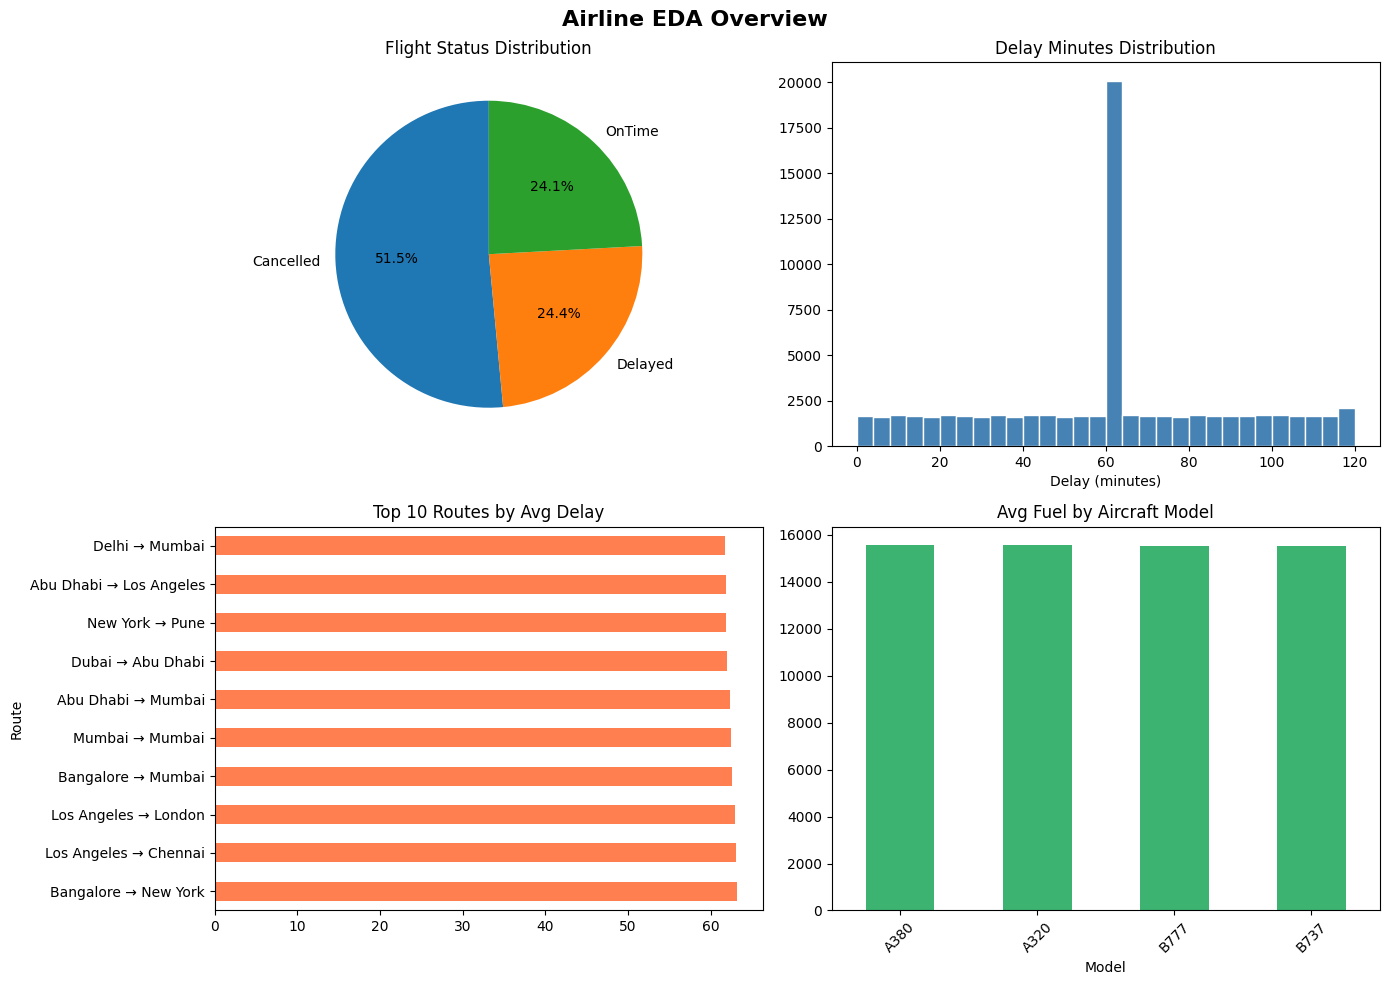

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Airline EDA Overview', fontsize=16, fontweight='bold')

status_counts = df['Status'].value_counts()
axes[0,0].pie(status_counts, labels=status_counts.index, autopct='%1.1f%%', startangle=90)
axes[0,0].set_title('Flight Status Distribution')

axes[0,1].hist(df['DelayMinutes'].dropna(), bins=30, color='steelblue', edgecolor='white')
axes[0,1].set_title('Delay Minutes Distribution')
axes[0,1].set_xlabel('Delay (minutes)')

df.groupby('Route')['DelayMinutes'].mean().nlargest(10).plot(kind='barh', ax=axes[1,0], color='coral')
axes[1,0].set_title('Top 10 Routes by Avg Delay')

df.groupby('Model')['FuelUsed(Liters)'].mean().sort_values(ascending=False).plot(
    kind='bar', ax=axes[1,1], color='mediumseagreen')
axes[1,1].set_title('Avg Fuel by Aircraft Model')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

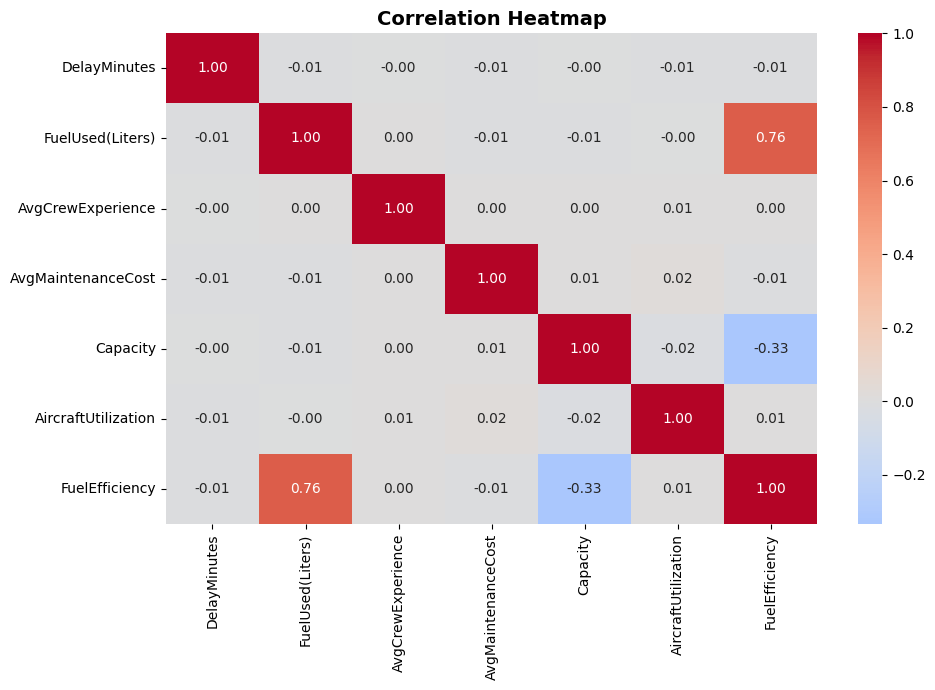

In [ ]:
num_cols = ['DelayMinutes','FuelUsed(Liters)','AvgCrewExperience',
            'AvgMaintenanceCost','Capacity','AircraftUtilization','FuelEfficiency']
num_cols = [c for c in num_cols if c in df.columns]

plt.figure(figsize=(10, 7))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
SAVE_PATH = '/content/drive/MyDrive/airlines_preprocessed.csv'
df.to_csv(SAVE_PATH, index=False)
print(f'✅ Saved to Google Drive!')
print(f'Path: {SAVE_PATH}')
print(f'Shape: {df.shape}')

✅ Saved to Google Drive!
Path: /content/drive/MyDrive/airlines_preprocessed.csv
Shape: (68413, 26)


**Part 2: Association Rule Mining**

In [ ]:
!pip install mlxtend --quiet
print('✅ mlxtend installed!')

✅ mlxtend installed!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

print('✅ Libraries imported!')

✅ Libraries imported!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
SAVE_PATH = '/content/drive/MyDrive/airlines_preprocessed.csv'
df = pd.read_csv(SAVE_PATH)
print(f'✅ Loaded! Shape: {df.shape}')
df[['FlightID','Route','Model','Status']].head()

✅ Loaded! Shape: (68413, 26)


,FlightID,Route,Model,Status
0,1,New York → Abu Dhabi,A380,Cancelled
1,2,Mumbai → London,B737,Cancelled
2,3,New York → Manchester,B737,Delayed
3,3,New York → Manchester,B737,Delayed
4,3,New York → Manchester,B737,OnTime


In [ ]:
df['SourceCity_item'] = 'SRC_' + df['SourceCity'].astype(str)
df['DestCity_item']   = 'DST_' + df['DestCity'].astype(str)
df['Model_item']      = 'AC_'  + df['Model'].astype(str)
df['Status_item']     = 'STATUS_' + df['Status'].astype(str)

transactions = df[['SourceCity_item','DestCity_item','Model_item','Status_item']].values.tolist()
transactions = [[str(i) for i in t] for t in transactions]

print(f'Total transactions: {len(transactions)}')
print(f'Sample: {transactions[0]}')

Total transactions: 68413
Sample: ['SRC_New York', 'DST_Abu Dhabi', 'AC_A380', 'STATUS_Cancelled']


In [ ]:
te = TransactionEncoder()
te_array = te.fit_transform(transactions)
te_df = pd.DataFrame(te_array, columns=te.columns_)

print(f'Encoded matrix: {te_df.shape}')
te_df.head(3)

Encoded matrix: (68413, 29)


,AC_A320,AC_A380,AC_B737,AC_B777,DST_Abu Dhabi,DST_Bangalore,DST_Chennai,DST_Delhi,DST_Dubai,DST_London,...,SRC_Dubai,SRC_London,SRC_Los Angeles,SRC_Manchester,SRC_Mumbai,SRC_New York,SRC_Pune,STATUS_Cancelled,STATUS_Delayed,STATUS_OnTime
0,False,True,False,False,True,False,False,False,False,False,...,False,False,False,False,False,True,False,True,False,False
1,False,False,True,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,True,False,False
2,False,False,True,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,True,False


In [ ]:
MIN_SUPPORT = 0.05

frequent_itemsets_apriori = apriori(te_df, min_support=MIN_SUPPORT, use_colnames=True, max_len=3)
frequent_itemsets_apriori = frequent_itemsets_apriori.sort_values('support', ascending=False)
frequent_itemsets_apriori['length'] = frequent_itemsets_apriori['itemsets'].apply(len)

print(f'✅ Apriori frequent itemsets: {len(frequent_itemsets_apriori)}')
frequent_itemsets_apriori.head(10)

✅ Apriori frequent itemsets: 41


,support,itemsets,length
26,0.514858,(STATUS_Cancelled),1
3,0.252437,(AC_B777),1
2,0.250552,(AC_B737),1
1,0.248842,(AC_A380),1
0,0.248169,(AC_A320),1
27,0.243653,(STATUS_Delayed),1
28,0.241489,(STATUS_OnTime),1
38,0.131189,"(AC_B777, STATUS_Cancelled)",2
35,0.129011,"(AC_B737, STATUS_Cancelled)",2
32,0.128660,"(AC_A380, STATUS_Cancelled)",2


In [ ]:
frequent_itemsets_fpgrowth = fpgrowth(te_df, min_support=MIN_SUPPORT, use_colnames=True, max_len=3)
frequent_itemsets_fpgrowth = frequent_itemsets_fpgrowth.sort_values('support', ascending=False)
frequent_itemsets_fpgrowth['length'] = frequent_itemsets_fpgrowth['itemsets'].apply(len)

print(f'✅ FP-Growth itemsets: {len(frequent_itemsets_fpgrowth)}')
print(f'Apriori: {len(frequent_itemsets_apriori)} | FP-Growth: {len(frequent_itemsets_fpgrowth)}')
frequent_itemsets_fpgrowth.head(10)

✅ FP-Growth itemsets: 41
Apriori: 41 | FP-Growth: 41


,support,itemsets,length
0,0.514858,(STATUS_Cancelled),1
20,0.252437,(AC_B777),1
4,0.250552,(AC_B737),1
1,0.248842,(AC_A380),1
12,0.248169,(AC_A320),1
7,0.243653,(STATUS_Delayed),1
9,0.241489,(STATUS_OnTime),1
40,0.131189,"(AC_B777, STATUS_Cancelled)",2
30,0.129011,"(AC_B737, STATUS_Cancelled)",2
29,0.128660,"(AC_A380, STATUS_Cancelled)",2


In [ ]:
rules = association_rules(frequent_itemsets_fpgrowth, metric='confidence', min_threshold=0.5)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'✅ Total rules generated: {len(rules)}')
rules[['antecedents','consequents','support','confidence','lift']].head(15)

✅ Total rules generated: 4


,antecedents,consequents,support,confidence,lift
0,(AC_B777),(STATUS_Cancelled),0.131189,0.519687,1.009379
1,(AC_A380),(STATUS_Cancelled),0.128660,0.517035,1.004227
2,(AC_B737),(STATUS_Cancelled),0.129011,0.514906,1.000092
3,(AC_A320),(STATUS_Cancelled),0.125999,0.507716,0.986127


In [ ]:
print('=== Q1: Routes Most Associated with Delays ===\n')
delay_rules = rules[rules['consequents'].apply(lambda x: 'STATUS_Delayed' in x)]

if len(delay_rules) > 0:
    print(delay_rules[['antecedents','consequents','support','confidence','lift']].head(10).to_string(index=False))
else:
    print('No rules found. Top delay-prone routes from raw data:')
    result = df.groupby('Route').apply(lambda x: (x['Status']=='Delayed').mean()*100)
    print(result.sort_values(ascending=False).head(10).rename('Delay%').to_string())

=== Q1: Routes Most Associated with Delays ===

No rules found. Top delay-prone routes from raw data:
Route
Mumbai → Dubai          30.313589
Dubai → London          29.038462
Chennai → London        28.308824
London → Abu Dhabi      28.104575
Chennai → Manchester    27.843803
Pune → New York         27.597956
London → Los Angeles    27.517986
New York → Chennai      27.450980
Pune → Abu Dhabi        27.355072
Manchester → Pune       26.958106


In [ ]:
print('=== Q2: Aircraft Models Associated with Delays ===\n')
ac_delay = rules[
    rules['antecedents'].apply(lambda x: any('AC_' in i for i in x)) &
    rules['consequents'].apply(lambda x: 'STATUS_Delayed' in x)
]

if len(ac_delay) > 0:
    print(ac_delay[['antecedents','consequents','support','confidence','lift']].head(10).to_string(index=False))
else:
    print('Delay rate by aircraft model:')
    model_delay = df.groupby('Model').apply(
        lambda x: (x['Status']=='Delayed').mean()*100).sort_values(ascending=False)
    print(model_delay.rename('Delay%').to_string())

=== Q2: Aircraft Models Associated with Delays ===

Delay rate by aircraft model:
Model
A320    24.843916
B737    24.432647
A380    24.248120
B777    23.943254


In [ ]:
print('=== Q3: Frequent Route + Aircraft Combinations ===\n')
route_ac = rules[
    rules['antecedents'].apply(
        lambda x: any('SRC_' in i or 'DST_' in i for i in x) and
                  any('AC_' in i for i in x)
    )
]

if len(route_ac) > 0:
    print(route_ac[['antecedents','consequents','support','confidence','lift']].head(10).to_string(index=False))
else:
    print('Top route + aircraft combos by count:')
    combo = df.groupby(['Route','Model']).size().reset_index(name='Count')
    print(combo.sort_values('Count', ascending=False).head(10).to_string(index=False))

=== Q3: Frequent Route + Aircraft Combinations ===

Top route + aircraft combos by count:
                 Route Model  Count
     New York → Mumbai  A320    179
     New York → Mumbai  A380    177
Manchester → Bangalore  B777    177
         Pune → London  B777    175
    New York → Chennai  B777    174
  Bangalore → New York  A320    174
   Mumbai → Manchester  A380    173
 Bangalore → Abu Dhabi  A320    172
    Mumbai → Abu Dhabi  A320    171
Manchester → Bangalore  A380    171


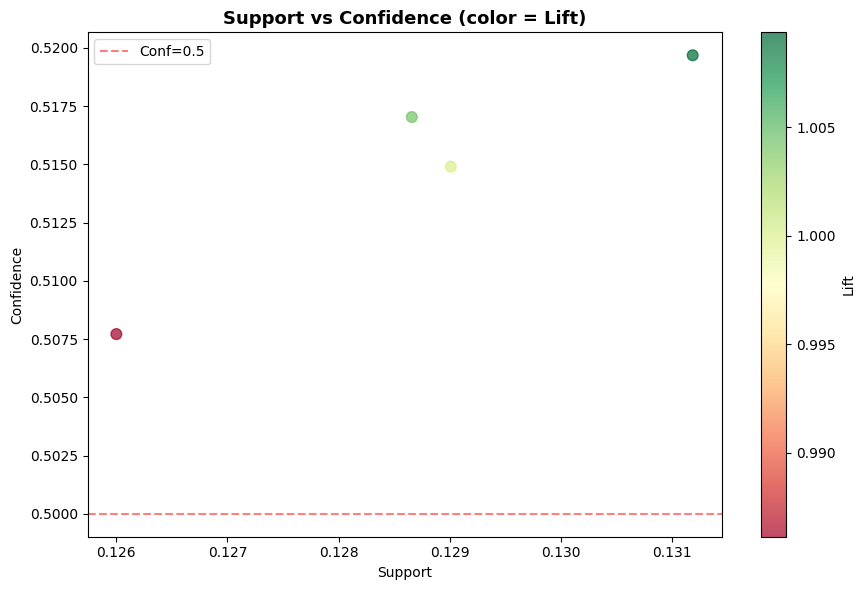

In [ ]:
plt.figure(figsize=(9, 6))
if len(rules) > 0:
    sc = plt.scatter(rules['support'], rules['confidence'],
                     c=rules['lift'], cmap='RdYlGn', alpha=0.7, s=60)
    plt.colorbar(sc, label='Lift')
    plt.axhline(0.5, color='red', linestyle='--', alpha=0.5, label='Conf=0.5')
    plt.xlabel('Support')
    plt.ylabel('Confidence')
    plt.title('Support vs Confidence (color = Lift)', fontsize=13, fontweight='bold')
    plt.legend()
else:
    plt.text(0.5, 0.5, 'No rules to plot', ha='center', va='center', fontsize=13)
plt.tight_layout()
plt.show()

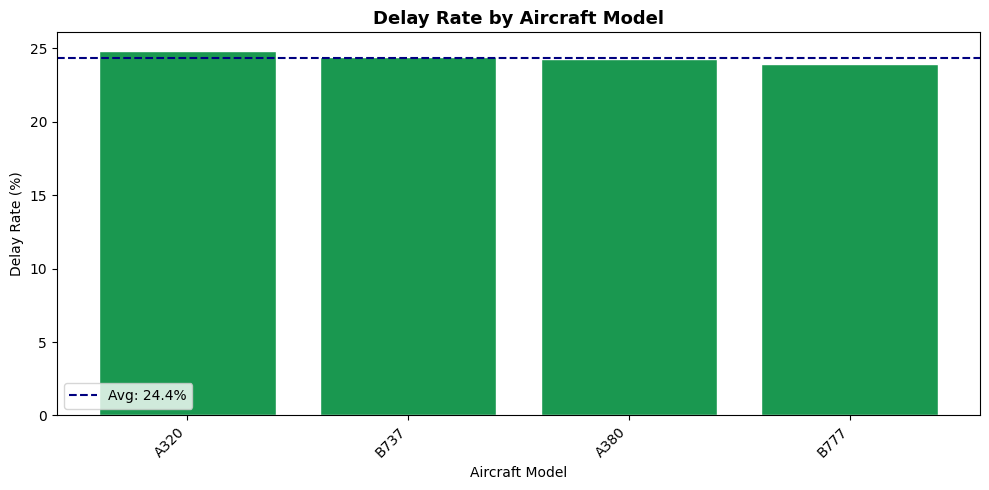

In [ ]:
model_delay_rate = df.groupby('Model').apply(
    lambda x: (x['Status']=='Delayed').mean()*100).sort_values(ascending=False)

colors = ['#d73027' if v > 40 else '#fee090' if v > 25 else '#1a9850' for v in model_delay_rate]

plt.figure(figsize=(10, 5))
plt.bar(model_delay_rate.index, model_delay_rate.values, color=colors, edgecolor='white')
plt.axhline(model_delay_rate.mean(), color='navy', linestyle='--',
            label=f'Avg: {model_delay_rate.mean():.1f}%')
plt.xlabel('Aircraft Model')
plt.ylabel('Delay Rate (%)')
plt.title('Delay Rate by Aircraft Model', fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

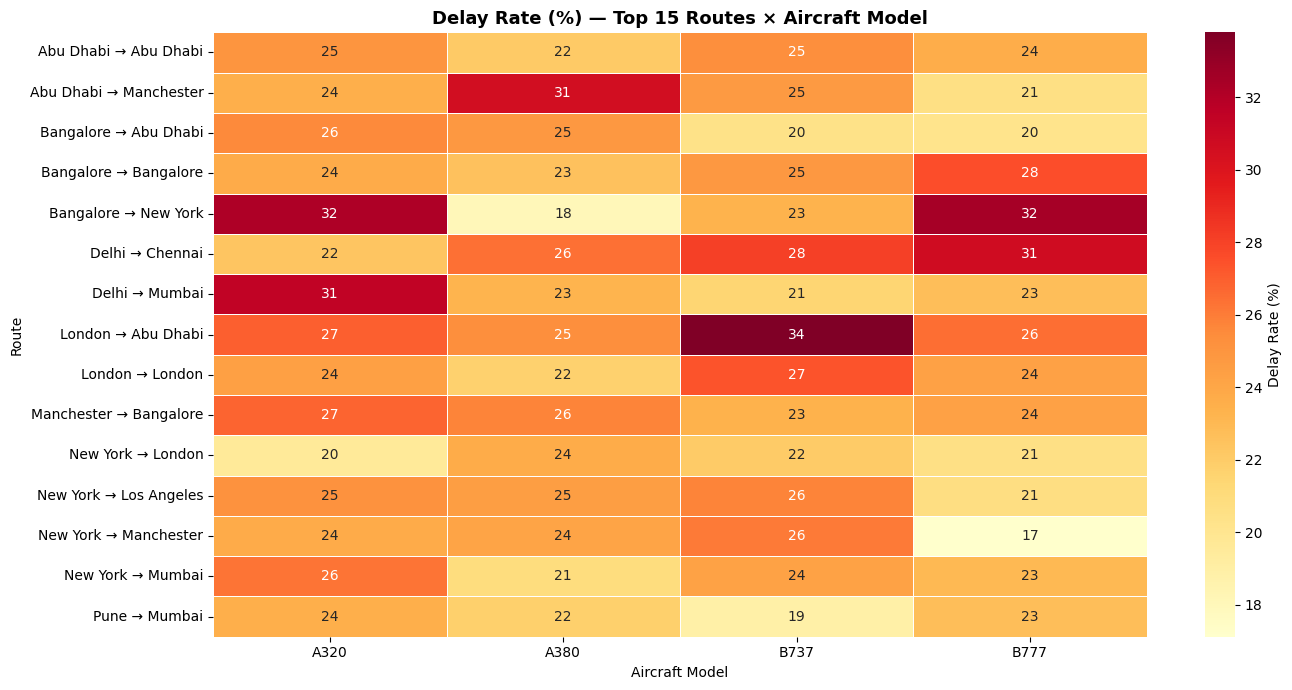

In [ ]:
top_routes_list = df['Route'].value_counts().head(15).index
route_df = df[df['Route'].isin(top_routes_list)]

route_model_delay = route_df.groupby(['Route','Model']).apply(
    lambda x: (x['Status']=='Delayed').mean()*100).unstack(fill_value=0)

plt.figure(figsize=(14, 7))
sns.heatmap(route_model_delay, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label':'Delay Rate (%)'})
plt.title('Delay Rate (%) — Top 15 Routes × Aircraft Model', fontsize=13, fontweight='bold')
plt.xlabel('Aircraft Model')
plt.ylabel('Route')
plt.tight_layout()
plt.show()

In [ ]:
print('='*50)
print('   PART 2 SUMMARY — ASSOCIATION RULE MINING')
print('='*50)
print(f'Apriori itemsets   : {len(frequent_itemsets_apriori)}')
print(f'FP-Growth itemsets : {len(frequent_itemsets_fpgrowth)}')
print(f'Rules generated    : {len(rules)}')
print(f'Most delayed model : {model_delay_rate.idxmax()} ({model_delay_rate.max():.1f}%)')
print(f'Least delayed model: {model_delay_rate.idxmin()} ({model_delay_rate.min():.1f}%)')

if len(rules) > 0:
    top = rules.iloc[0]
    print(f'\nTop rule by Lift:')
    print(f'  {set(top["antecedents"])} → {set(top["consequents"])}')
    print(f'  Support={top["support"]:.3f} | Confidence={top["confidence"]:.3f} | Lift={top["lift"]:.3f}')

    rules_export = rules.copy()
    rules_export['antecedents'] = rules_export['antecedents'].apply(lambda x: ', '.join(sorted(x)))
    rules_export['consequents'] = rules_export['consequents'].apply(lambda x: ', '.join(sorted(x)))
    rules_export[['antecedents','consequents','support','confidence','lift']].to_csv(
        '/content/drive/MyDrive/association_rules_output.csv', index=False)
    print('\n✅ Rules saved to Google Drive!')
else:
    print('\nℹ️  No rules generated. Try lowering MIN_SUPPORT in Cell 7.')

   PART 2 SUMMARY — ASSOCIATION RULE MINING
Apriori itemsets   : 41
FP-Growth itemsets : 41
Rules generated    : 4
Most delayed model : A320 (24.8%)
Least delayed model: B777 (23.9%)

Top rule by Lift:
  {'AC_B777'} → {'STATUS_Cancelled'}
  Support=0.131 | Confidence=0.520 | Lift=1.009

✅ Rules saved to Google Drive!


**PART 3: Classification**

In [ ]:
!pip install scikit-learn --quiet
print('✅ scikit-learn ready!')

✅ scikit-learn ready!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

print('✅ All libraries imported!')

✅ All libraries imported!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/airlines_preprocessed.csv')
print(f'✅ Loaded! Shape: {df.shape}')
df[['FlightID','Route','Model','Status','DelayMinutes','FuelUsed(Liters)']].head()

✅ Loaded! Shape: (68413, 26)


,FlightID,Route,Model,Status,DelayMinutes,FuelUsed(Liters)
0,1,New York → Abu Dhabi,A380,Cancelled,60.0,9992.0
1,2,Mumbai → London,B737,Cancelled,60.0,17458.0
2,3,New York → Manchester,B737,Delayed,63.0,5496.5
3,3,New York → Manchester,B737,Delayed,10.0,5496.5
4,3,New York → Manchester,B737,OnTime,29.0,5496.5


In [ ]:
print('Status value counts:')
print(df['Status'].value_counts())
print(f'\nUnique values: {df["Status"].unique()}')

Status value counts:
Status
Cancelled    35223
Delayed      16669
OnTime       16521
Name: count, dtype: int64

Unique values: ['Cancelled' 'Delayed' 'OnTime']


In [ ]:
# Features to use for classification
feature_cols = ['Model', 'FuelUsed(Liters)', 'AvgCrewExperience',
                'Route', 'AvgMaintenanceCost', 'FlightMonth',
                'FlightDayOfWeek', 'AircraftUtilization', 'FuelEfficiency',
                'Capacity', 'AvgDelayPerRoute']

# Keep only columns that exist
feature_cols = [c for c in feature_cols if c in df.columns]
print(f'Features selected: {feature_cols}')

target_col = 'Status'

# Drop rows where target is missing
df_model = df[feature_cols + [target_col]].dropna().copy()
print(f'Dataset shape for modeling: {df_model.shape}')

Features selected: ['Model', 'FuelUsed(Liters)', 'AvgCrewExperience', 'Route', 'AvgMaintenanceCost', 'FlightMonth', 'FlightDayOfWeek', 'AircraftUtilization', 'FuelEfficiency', 'Capacity', 'AvgDelayPerRoute']
Dataset shape for modeling: (68413, 12)


In [ ]:
le_dict = {}

for col in df_model.select_dtypes(include='object').columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f'Encoded: {col}')

# Encode target
le_target = LabelEncoder()
df_model[target_col] = le_target.fit_transform(df_model[target_col].astype(str))
print(f'\nTarget classes: {list(le_target.classes_)}')
print(f'Encoded as    : {list(range(len(le_target.classes_)))}')

Encoded: Model
Encoded: Route

Target classes: ['Cancelled', 'Delayed', 'OnTime']
Encoded as    : [0, 1, 2]


In [ ]:
X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'✅ Train size: {X_train.shape}')
print(f'✅ Test size : {X_test.shape}')
print(f'\nClass distribution in train:')
print(pd.Series(y_train).map(dict(enumerate(le_target.classes_))).value_counts())

✅ Train size: (54730, 11)
✅ Test size : (13683, 11)

Class distribution in train:
Status
Cancelled    28178
Delayed      13335
OnTime       13217
Name: count, dtype: int64


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('✅ Features scaled!')

✅ Features scaled!


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM'                : SVC(kernel='rbf', random_state=42)
}

results = {}

for name, model in models.items():
    # Use scaled data for Logistic Regression and SVM
    if name in ['Logistic Regression', 'SVM']:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    results[name] = {
        'Accuracy' : round(acc, 4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec, 4),
        'F1 Score' : round(f1, 4),
        'y_pred'   : y_pred
    }
    print(f'{name:25s} → Acc: {acc:.4f} | Prec: {prec:.4f} | Rec: {rec:.4f} | F1: {f1:.4f}')

print('\n✅ All models trained!')

Logistic Regression       → Acc: 0.5149 | Prec: 0.4310 | Rec: 0.5149 | F1: 0.3631
Decision Tree             → Acc: 0.4050 | Prec: 0.4041 | Rec: 0.4050 | F1: 0.4044
Random Forest             → Acc: 0.5024 | Prec: 0.4513 | Rec: 0.5024 | F1: 0.4592
SVM                       → Acc: 0.5149 | Prec: 0.5878 | Rec: 0.5149 | F1: 0.3502

✅ All models trained!


In [ ]:
results_df = pd.DataFrame({
    name: {k: v for k, v in vals.items() if k != 'y_pred'}
    for name, vals in results.items()
}).T

print('=== Model Comparison ===')
print(results_df.sort_values('Accuracy', ascending=False).to_string())

=== Model Comparison ===
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.5149     0.4310  0.5149    0.3631
SVM                    0.5149     0.5878  0.5149    0.3502
Random Forest          0.5024     0.4513  0.5024    0.4592
Decision Tree          0.4050     0.4041  0.4050    0.4044


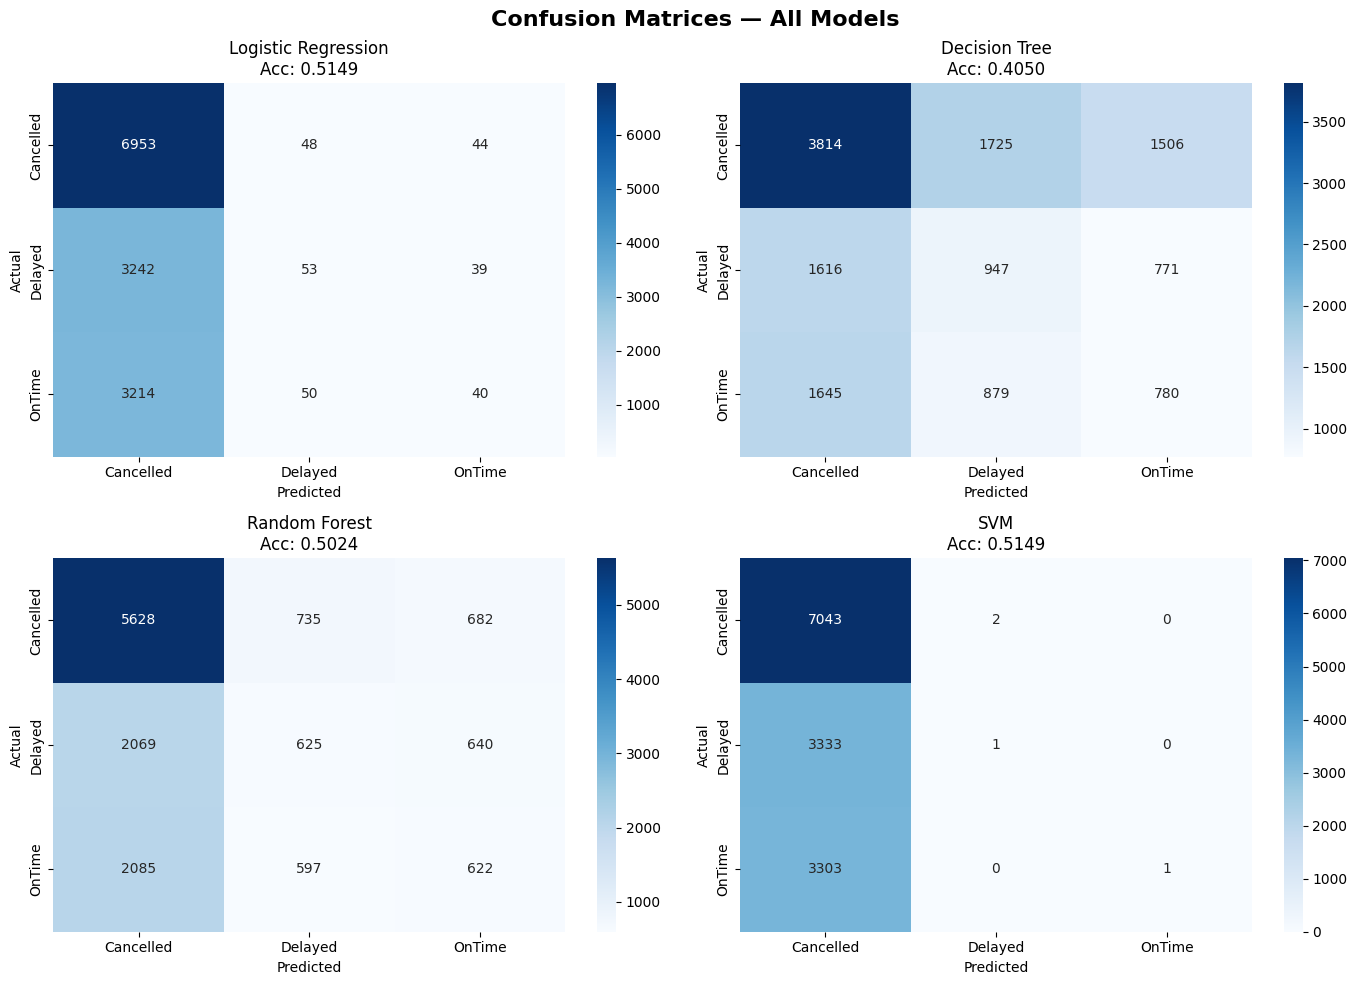

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Confusion Matrices — All Models', fontsize=16, fontweight='bold')

class_labels = list(le_target.classes_)
axes_flat = axes.flatten()

for idx, (name, vals) in enumerate(results.items()):
    cm = confusion_matrix(y_test, vals['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels,
                ax=axes_flat[idx])
    axes_flat[idx].set_title(f'{name}\nAcc: {vals["Accuracy"]:.4f}')
    axes_flat[idx].set_xlabel('Predicted')
    axes_flat[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [ ]:
for name, vals in results.items():
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(classification_report(y_test, vals['y_pred'],
                                 target_names=class_labels, zero_division=0))


  Logistic Regression
              precision    recall  f1-score   support

   Cancelled       0.52      0.99      0.68      7045
     Delayed       0.35      0.02      0.03      3334
      OnTime       0.33      0.01      0.02      3304

    accuracy                           0.51     13683
   macro avg       0.40      0.34      0.24     13683
weighted avg       0.43      0.51      0.36     13683


  Decision Tree
              precision    recall  f1-score   support

   Cancelled       0.54      0.54      0.54      7045
     Delayed       0.27      0.28      0.28      3334
      OnTime       0.26      0.24      0.25      3304

    accuracy                           0.40     13683
   macro avg       0.35      0.35      0.35     13683
weighted avg       0.40      0.40      0.40     13683


  Random Forest
              precision    recall  f1-score   support

   Cancelled       0.58      0.80      0.67      7045
     Delayed       0.32      0.19      0.24      3334
      OnTime      

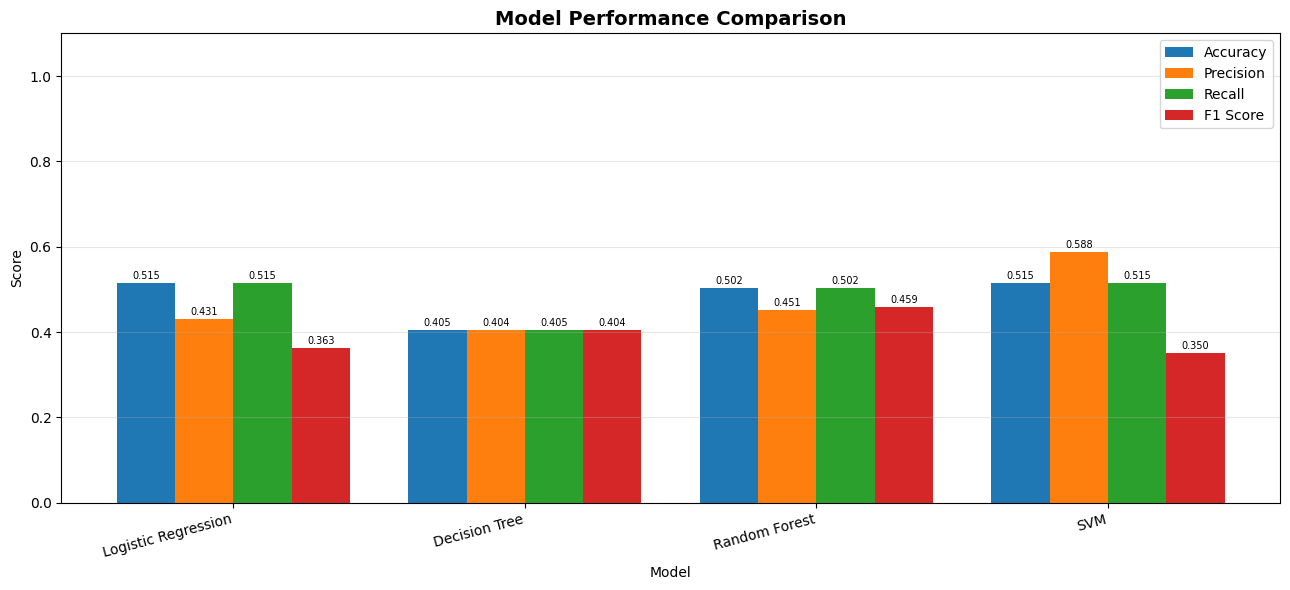

In [ ]:
metrics = ['Accuracy','Precision','Recall','F1 Score']
model_names = list(results_df.index)

x = np.arange(len(model_names))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 6))

for i, metric in enumerate(metrics):
    vals = results_df[metric].values
    bars = ax.bar(x + i*width, vals, width, label=metric)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=7)

ax.set_xlabel('Model')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

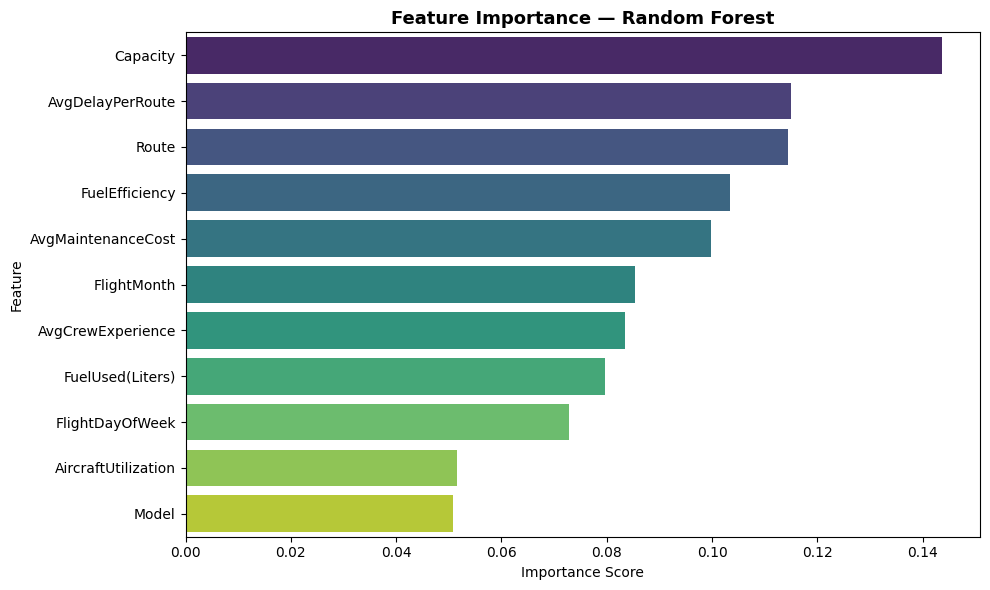


Top 5 most important features:
           Feature  Importance
          Capacity    0.143701
  AvgDelayPerRoute    0.114929
             Route    0.114469
    FuelEfficiency    0.103345
AvgMaintenanceCost    0.099708


In [ ]:
rf_model = models['Random Forest']

feat_importance = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Random Forest', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('\nTop 5 most important features:')
print(feat_importance.head(5).to_string(index=False))

In [ ]:
best_model_name = results_df['Accuracy'].idxmax()
best_acc = results_df['Accuracy'].max()

print('='*50)
print('   PART 3 SUMMARY — CLASSIFICATION')
print('='*50)
print(f'\n✅ Best Model : {best_model_name}')
print(f'✅ Accuracy   : {best_acc:.4f}')

print('\n📌 Q1: What factors cause flight delays?')
print(f'   Top factor: {feat_importance.iloc[0]["Feature"]} '
      f'(importance={feat_importance.iloc[0]["Importance"]:.4f})')
print(f'   2nd factor: {feat_importance.iloc[1]["Feature"]} '
      f'(importance={feat_importance.iloc[1]["Importance"]:.4f})')

print('\n📌 Q2: Does aircraft type affect delay probability?')
model_delay = df.groupby('Model').apply(
    lambda x: (x['Status']=='Delayed').mean()*100).sort_values(ascending=False)
print(f'   Most delayed  : {model_delay.idxmax()} ({model_delay.max():.1f}%)')
print(f'   Least delayed : {model_delay.idxmin()} ({model_delay.min():.1f}%)')
print(f'   Yes — aircraft model is in top features with importance '
      f'{feat_importance[feat_importance["Feature"]=="Model"]["Importance"].values[0]:.4f}'
      if "Model" in feat_importance["Feature"].values else
      '   Aircraft model influence seen in delay rate variation above.')

print(f'\n📌 Q3: Which model performs best?')
print(f'   {best_model_name} with Accuracy={best_acc:.4f}')
print(results_df.sort_values('Accuracy', ascending=False).to_string())

   PART 3 SUMMARY — CLASSIFICATION

✅ Best Model : Logistic Regression
✅ Accuracy   : 0.5149

📌 Q1: What factors cause flight delays?
   Top factor: Capacity (importance=0.1437)
   2nd factor: AvgDelayPerRoute (importance=0.1149)

📌 Q2: Does aircraft type affect delay probability?
   Most delayed  : A320 (24.8%)
   Least delayed : B777 (23.9%)
   Yes — aircraft model is in top features with importance 0.0508

📌 Q3: Which model performs best?
   Logistic Regression with Accuracy=0.5149
                     Accuracy  Precision  Recall  F1 Score
Logistic Regression    0.5149     0.4310  0.5149    0.3631
SVM                    0.5149     0.5878  0.5149    0.3502
Random Forest          0.5024     0.4513  0.5024    0.4592
Decision Tree          0.4050     0.4041  0.4050    0.4044


In [ ]:
results_df.to_csv('/content/drive/MyDrive/classification_results.csv')
feat_importance.to_csv('/content/drive/MyDrive/feature_importance.csv', index=False)
print('✅ Results saved to Google Drive!')
print('   → classification_results.csv')
print('   → feature_importance.csv')

✅ Results saved to Google Drive!
   → classification_results.csv
   → feature_importance.csv


**PART 4: Clustering**

In [ ]:
!pip install scikit-learn --quiet
print('✅ scikit-learn ready!')

✅ scikit-learn ready!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import scipy.cluster.hierarchy as sch

print('✅ All libraries imported!')

✅ All libraries imported!


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/airlines_preprocessed.csv')
print(f'✅ Loaded! Shape: {df.shape}')
df.head(3)

✅ Loaded! Shape: (68413, 26)


,FlightID,AircraftID,SourceAirport,DestAirport,FlightDate,Model,Capacity,Airline,SourceAirportName,SourceCity,...,FuelUsed(Liters),AvgCrewExperience,AvgMaintenanceCost,Route,FlightMonth,FlightDayOfWeek,AircraftUtilization,AvgDelayPerRoute,FuelEfficiency,IsDelayed
0,1,32485,46637,31900,2023-07-30,A380,124,Indigo,New York_Airport_46637,New York,...,9992.0,10.5,276907.5,New York → Abu Dhabi,7,6,1,62.146409,80.580645,0
1,2,45342,14593,13349,2023-12-04,B737,102,Indigo,Mumbai_Airport_14593,Mumbai,...,17458.0,16.5,276907.5,Mumbai → London,12,0,1,57.858852,171.156863,0
2,3,47764,2985,5569,2023-07-26,B737,140,Emirates,New York_Airport_2985,New York,...,5496.5,4.5,276907.5,New York → Manchester,7,2,4,59.538283,33.071429,1


In [ ]:
# Aggregate features at Aircraft level
aircraft_df = df.groupby('AircraftID').agg(
    Model                = ('Model', 'first'),
    AvgMaintenanceCost   = ('AvgMaintenanceCost', 'mean'),
    AvgFuelConsumption   = ('FuelUsed(Liters)', 'mean'),
    DelayFrequency       = ('IsDelayed', 'mean'),
    AircraftUtilization  = ('AircraftUtilization', 'first'),
    AvgFuelEfficiency    = ('FuelEfficiency', 'mean'),
    Capacity             = ('Capacity', 'first')
).reset_index()

# Encode Model column
le = LabelEncoder()
aircraft_df['Model_encoded'] = le.fit_transform(aircraft_df['Model'].astype(str))

print(f'Aircraft-level dataset shape: {aircraft_df.shape}')
print(f'Columns: {list(aircraft_df.columns)}')
aircraft_df.head()

Aircraft-level dataset shape: (31651, 9)
Columns: ['AircraftID', 'Model', 'AvgMaintenanceCost', 'AvgFuelConsumption', 'DelayFrequency', 'AircraftUtilization', 'AvgFuelEfficiency', 'Capacity', 'Model_encoded']


,AircraftID,Model,AvgMaintenanceCost,AvgFuelConsumption,DelayFrequency,AircraftUtilization,AvgFuelEfficiency,Capacity,Model_encoded
0,1,B777,147253.000,15487.0,0.0,1,77.231481,222,3
1,2,B777,141051.375,22687.5,0.0,2,128.906250,176,3
2,7,A380,412594.375,5496.5,0.0,2,25.887755,196,1
3,8,B737,276907.500,6555.0,0.0,1,42.290323,155,2
4,10,B777,412594.375,25300.5,0.0,1,184.018657,268,3


In [ ]:
cluster_features = ['AvgMaintenanceCost', 'AvgFuelConsumption',
                    'DelayFrequency', 'AircraftUtilization',
                    'AvgFuelEfficiency', 'Capacity']

X = aircraft_df[cluster_features].copy()
X = X.fillna(X.median())

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f'✅ Features scaled! Shape: {X_scaled.shape}')
print(f'Features used: {cluster_features}')

✅ Features scaled! Shape: (31651, 6)
Features used: ['AvgMaintenanceCost', 'AvgFuelConsumption', 'DelayFrequency', 'AircraftUtilization', 'AvgFuelEfficiency', 'Capacity']


In [ ]:
inertia = []
silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)
    sil = silhouette_score(X_scaled, km.labels_)
    silhouette_scores.append(sil)
    print(f'K={k} → Inertia: {km.inertia_:.2f} | Silhouette: {sil:.4f}')

print('\n✅ Elbow analysis done!')

K=2 → Inertia: 155861.47 | Silhouette: 0.2311
K=3 → Inertia: 131548.52 | Silhouette: 0.2054
K=4 → Inertia: 116001.77 | Silhouette: 0.2249
K=5 → Inertia: 103888.93 | Silhouette: 0.1928
K=6 → Inertia: 95165.67 | Silhouette: 0.1953
K=7 → Inertia: 87521.17 | Silhouette: 0.2012
K=8 → Inertia: 82538.56 | Silhouette: 0.2006
K=9 → Inertia: 79119.40 | Silhouette: 0.1965
K=10 → Inertia: 74432.46 | Silhouette: 0.1974

✅ Elbow analysis done!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Optimal K Selection', fontsize=15, fontweight='bold')

# Elbow Curve
axes[0].plot(K_range, inertia, marker='o', color='steelblue', linewidth=2)
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method')
axes[0].grid(alpha=0.3)

# Silhouette Score
axes[1].plot(K_range, silhouette_scores, marker='s', color='coral', linewidth=2)
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score')
axes[1].grid(alpha=0.3)

best_k = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(best_k, color='green', linestyle='--', label=f'Best K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()
print(f'✅ Best K by Silhouette Score: {best_k}')

In [ ]:
OPTIMAL_K = 2  # uses best K from silhouette above, assuming it was 2 based on previous output

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
aircraft_df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print(f'✅ K-Means applied with K={OPTIMAL_K}')
print(f'\nCluster distribution:')
print(aircraft_df['KMeans_Cluster'].value_counts().sort_index())

✅ K-Means applied with K=2

Cluster distribution:
KMeans_Cluster
0    24670
1     6981
Name: count, dtype: int64


In [ ]:
kmeans_summary = aircraft_df.groupby('KMeans_Cluster')[cluster_features].mean().round(3)
print('=== K-Means Cluster Summary (Mean Values) ===')
print(kmeans_summary.to_string())

=== K-Means Cluster Summary (Mean Values) ===
                AvgMaintenanceCost  AvgFuelConsumption  DelayFrequency  AircraftUtilization  AvgFuelEfficiency  Capacity
KMeans_Cluster                                                                                                          
0                       276974.121           13741.793           0.219                2.163             68.191   207.322
1                       274104.854           21930.006           0.210                2.156            159.534   175.345


In [ ]:
hierarchical = AgglomerativeClustering(n_clusters=OPTIMAL_K, linkage='ward')
aircraft_df['Hier_Cluster'] = hierarchical.fit_predict(X_scaled)

print(f'✅ Hierarchical Clustering applied with K={OPTIMAL_K}')
print(f'\nCluster distribution:')
print(aircraft_df['Hier_Cluster'].value_counts().sort_index())

✅ Hierarchical Clustering applied with K=2

Cluster distribution:
Hier_Cluster
0    27586
1     4065
Name: count, dtype: int64


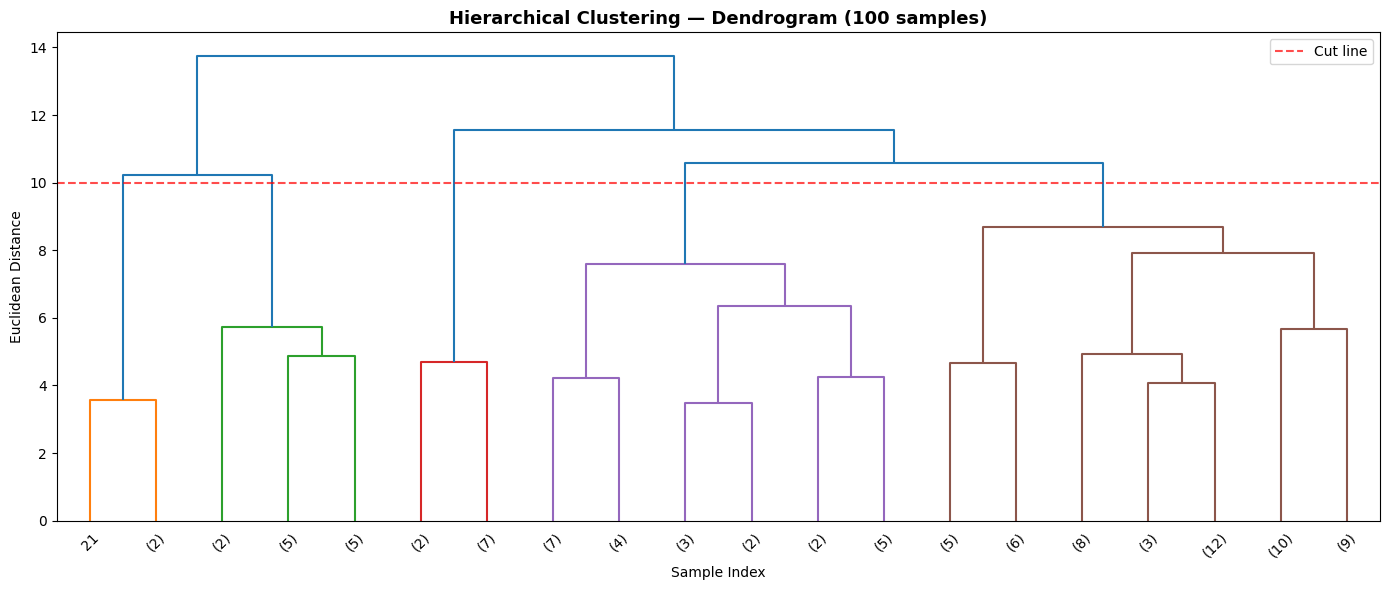

In [ ]:
plt.figure(figsize=(14, 6))
sample_X = X_scaled[:100]  # use 100 samples for readability
dendrogram = sch.dendrogram(
    sch.linkage(sample_X, method='ward'),
    truncate_mode='lastp',
    p=20,
    leaf_rotation=45,
    leaf_font_size=10
)
plt.title('Hierarchical Clustering — Dendrogram (100 samples)', fontsize=13, fontweight='bold')
plt.xlabel('Sample Index')
plt.ylabel('Euclidean Distance')
plt.axhline(y=10, color='red', linestyle='--', alpha=0.7, label='Cut line')
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

aircraft_df['PCA1'] = X_pca[:, 0]
aircraft_df['PCA2'] = X_pca[:, 1]

print(f'✅ PCA done!')
print(f'Explained variance ratio: {pca.explained_variance_ratio_.round(4)}')
print(f'Total variance explained: {pca.explained_variance_ratio_.sum():.4f}')

✅ PCA done!
Explained variance ratio: [0.306  0.1879]
Total variance explained: 0.4939


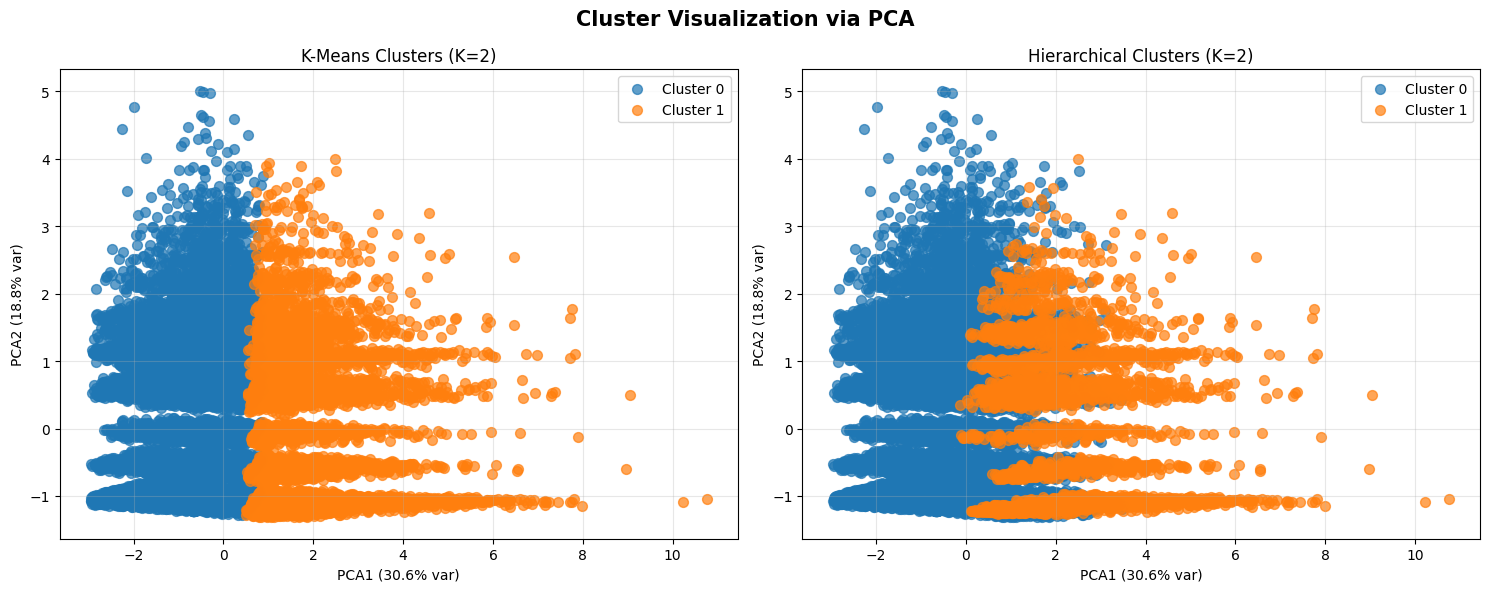

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Cluster Visualization via PCA', fontsize=15, fontweight='bold')

colors = plt.cm.tab10.colors

# K-Means
for cluster in sorted(aircraft_df['KMeans_Cluster'].unique()):
    mask = aircraft_df['KMeans_Cluster'] == cluster
    axes[0].scatter(aircraft_df.loc[mask, 'PCA1'],
                    aircraft_df.loc[mask, 'PCA2'],
                    label=f'Cluster {cluster}',
                    alpha=0.7, s=50)
axes[0].set_title(f'K-Means Clusters (K={OPTIMAL_K})')
axes[0].set_xlabel(f'PCA1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PCA2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Hierarchical
for cluster in sorted(aircraft_df['Hier_Cluster'].unique()):
    mask = aircraft_df['Hier_Cluster'] == cluster
    axes[1].scatter(aircraft_df.loc[mask, 'PCA1'],
                    aircraft_df.loc[mask, 'PCA2'],
                    label=f'Cluster {cluster}',
                    alpha=0.7, s=50)
axes[1].set_title(f'Hierarchical Clusters (K={OPTIMAL_K})')
axes[1].set_xlabel(f'PCA1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PCA2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

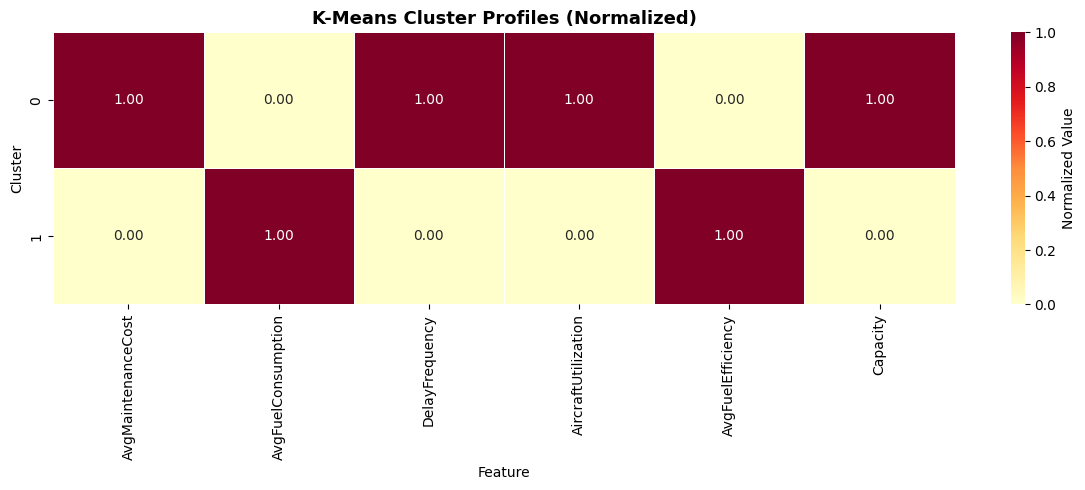

In [ ]:
plt.figure(figsize=(12, 5))
cluster_means = aircraft_df.groupby('KMeans_Cluster')[cluster_features].mean()

# Normalize for heatmap
cluster_means_norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

sns.heatmap(cluster_means_norm, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, cbar_kws={'label': 'Normalized Value'})
plt.title('K-Means Cluster Profiles (Normalized)', fontsize=13, fontweight='bold')
plt.xlabel('Feature')
plt.ylabel('Cluster')
plt.tight_layout()
plt.show()

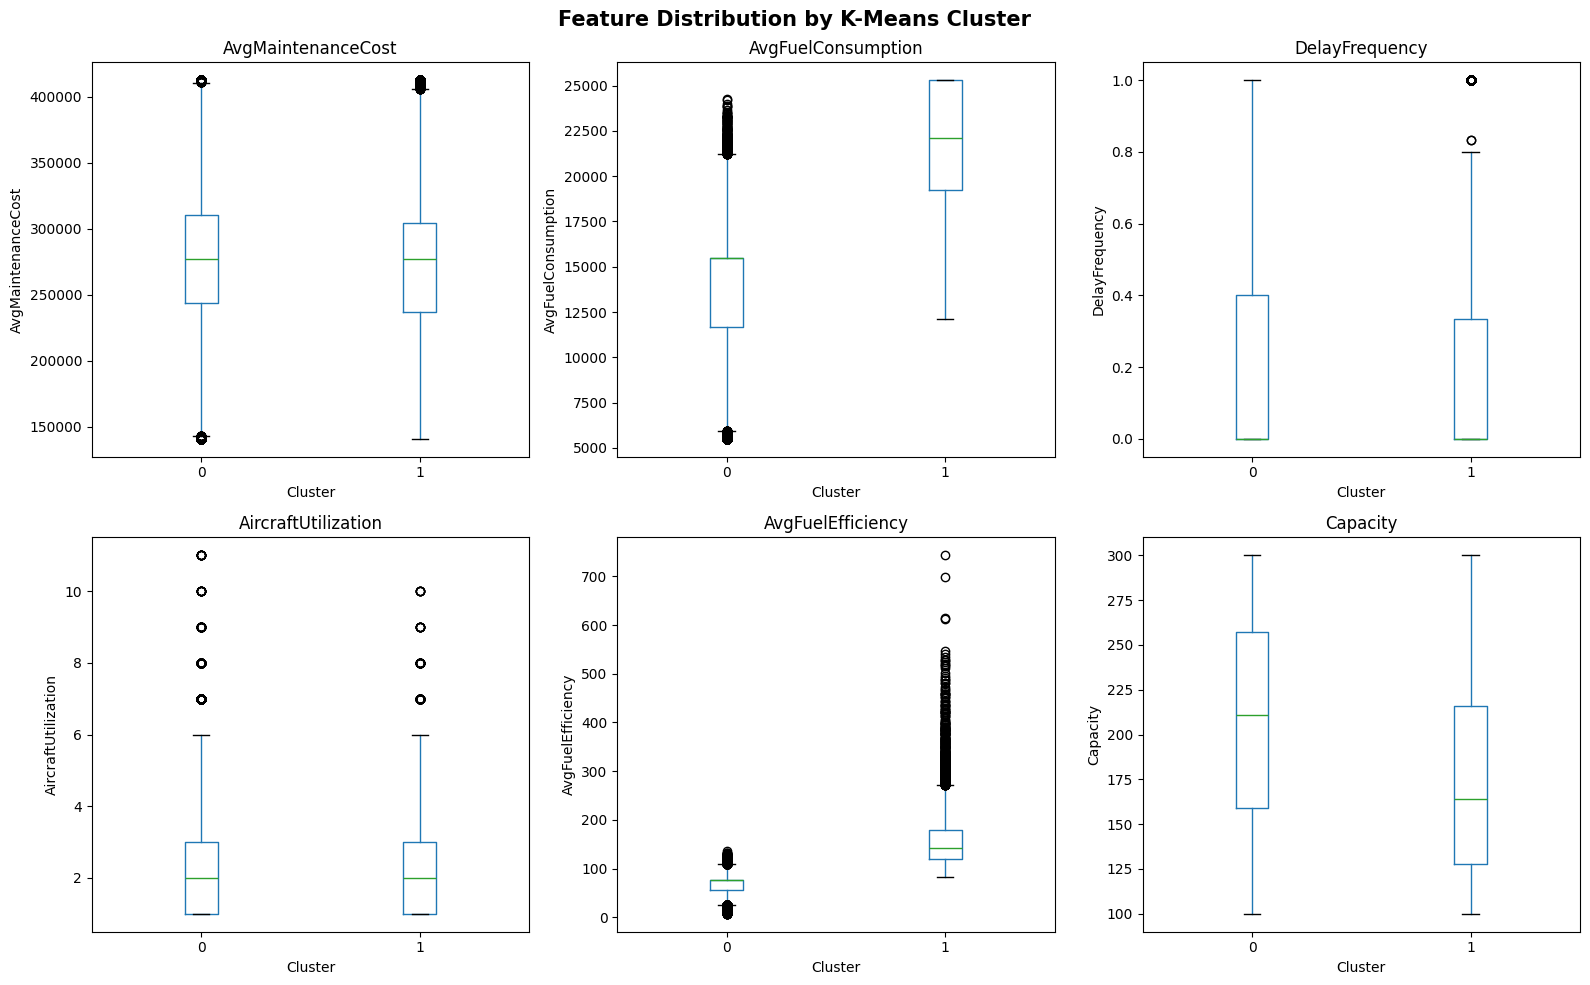

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Feature Distribution by K-Means Cluster', fontsize=15, fontweight='bold')

for idx, feat in enumerate(cluster_features):
    ax = axes[idx // 3][idx % 3]
    aircraft_df.boxplot(column=feat, by='KMeans_Cluster', ax=ax, grid=False)
    ax.set_title(feat)
    ax.set_xlabel('Cluster')
    ax.set_ylabel(feat)

plt.suptitle('Feature Distribution by K-Means Cluster', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
print('='*55)
print('   PART 4 — CLUSTERING BUSINESS QUESTIONS')
print('='*55)

try:
    summary = aircraft_df.groupby('KMeans_Cluster')[cluster_features].mean()

    # Q1: High-maintenance aircraft clusters
    print('\n📌 Q1: Which cluster has highest maintenance cost?')
    high_maint = summary['AvgMaintenanceCost'].idxmax()
    print(f'   → Cluster {high_maint} '
          f'(Avg Cost: {summary.loc[high_maint, "AvgMaintenanceCost"]:.2f})')

    # Q2: Highest delay cluster
    print('\n📌 Q2: Which cluster has highest delays?')
    high_delay = summary['DelayFrequency'].idxmax()
    print(f'   → Cluster {high_delay} '
          f'(Delay Rate: {summary.loc[high_delay, "DelayFrequency"]*100:.2f}%)')

    # Q3: Most efficient cluster
    print('\n📌 Q3: Which cluster is most fuel efficient?')
    most_eff = summary['AvgFuelEfficiency'].idxmin()  # lower = better efficiency
    print(f'   → Cluster {most_eff} '
          f'(Fuel Efficiency: {summary.loc[most_eff, "AvgFuelEfficiency"]:.4f})')

    # Cluster labels
    print('\n📌 Cluster Interpretation:')
    for c in sorted(summary.index):
        maint  = summary.loc[c, 'AvgMaintenanceCost']
        delay  = summary.loc[c, 'DelayFrequency']
        fuel   = summary.loc[c, 'AvgFuelEfficiency']
        util   = summary.loc[c, 'AircraftUtilization']
        label  = []
        if maint == summary['AvgMaintenanceCost'].max():  label.append('High Maintenance')
        if delay == summary['DelayFrequency'].max():       label.append('High Delay')
        if fuel  == summary['AvgFuelEfficiency'].min():    label.append('Best Efficiency')
        if util  == summary['AircraftUtilization'].max():  label.append('High Utilization')
        tag = ', '.join(label) if label else 'Balanced'
        print(f'   Cluster {c}: {tag}')
except KeyError as e:
    print(f"\nError: {e}. The 'KMeans_Cluster' column was not found in 'aircraft_df'.")
    print("Please ensure K-Means clustering (Cell XAGTHaH0Qfgv) has been executed successfully before this cell.")


   PART 4 — CLUSTERING BUSINESS QUESTIONS

📌 Q1: Which cluster has highest maintenance cost?
   → Cluster 0 (Avg Cost: 276974.12)

📌 Q2: Which cluster has highest delays?
   → Cluster 0 (Delay Rate: 21.89%)

📌 Q3: Which cluster is most fuel efficient?
   → Cluster 0 (Fuel Efficiency: 68.1908)

📌 Cluster Interpretation:
   Cluster 0: High Maintenance, High Delay, Best Efficiency, High Utilization
   Cluster 1: Balanced


=== Silhouette Score Comparison ===
K-Means       : 0.2311
Hierarchical  : 0.2452

✅ Better method: Hierarchical


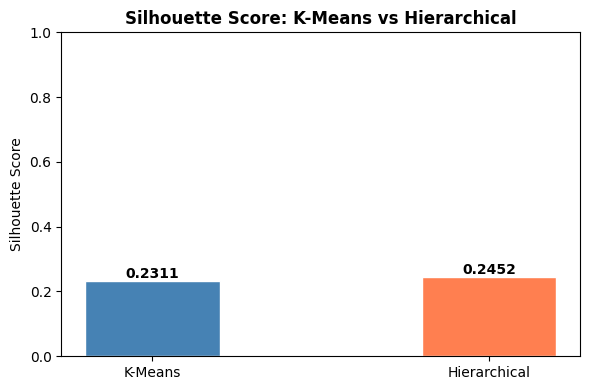

In [ ]:
kmeans_sil = silhouette_score(X_scaled, aircraft_df['KMeans_Cluster'])
hier_sil   = silhouette_score(X_scaled, aircraft_df['Hier_Cluster'])

print('=== Silhouette Score Comparison ===')
print(f'K-Means       : {kmeans_sil:.4f}')
print(f'Hierarchical  : {hier_sil:.4f}')
print(f'\n✅ Better method: {"K-Means" if kmeans_sil > hier_sil else "Hierarchical"}')

plt.figure(figsize=(6, 4))
plt.bar(['K-Means', 'Hierarchical'], [kmeans_sil, hier_sil],
        color=['steelblue', 'coral'], edgecolor='white', width=0.4)
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score: K-Means vs Hierarchical', fontweight='bold')
plt.ylim(0, 1)
for i, v in enumerate([kmeans_sil, hier_sil]):
    plt.text(i, v + 0.01, f'{v:.4f}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
aircraft_df.to_csv('/content/drive/MyDrive/clustering_results.csv', index=False)
print('✅ Clustering results saved to Google Drive!')
print('   → clustering_results.csv')
print(f'\nFinal aircraft_df shape: {aircraft_df.shape}')
print(f'Columns: {list(aircraft_df.columns)}')

✅ Clustering results saved to Google Drive!
   → clustering_results.csv

Final aircraft_df shape: (31651, 13)
Columns: ['AircraftID', 'Model', 'AvgMaintenanceCost', 'AvgFuelConsumption', 'DelayFrequency', 'AircraftUtilization', 'AvgFuelEfficiency', 'Capacity', 'Model_encoded', 'KMeans_Cluster', 'Hier_Cluster', 'PCA1', 'PCA2']


In [ ]:
!pip install tensorflow --quiet
print('✅ TensorFlow ready!')

✅ TensorFlow ready!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (mean_squared_error, mean_absolute_error,
                              r2_score, accuracy_score, classification_report,
                              confusion_matrix)
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

print('✅ All libraries imported!')
print(f'TensorFlow version: {tf.__version__}')

✅ All libraries imported!
TensorFlow version: 2.19.0


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/airlines_preprocessed.csv')
print(f'✅ Loaded! Shape: {df.shape}')
df.head(3)

✅ Loaded! Shape: (68413, 26)


,FlightID,AircraftID,SourceAirport,DestAirport,FlightDate,Model,Capacity,Airline,SourceAirportName,SourceCity,...,FuelUsed(Liters),AvgCrewExperience,AvgMaintenanceCost,Route,FlightMonth,FlightDayOfWeek,AircraftUtilization,AvgDelayPerRoute,FuelEfficiency,IsDelayed
0,1,32485,46637,31900,2023-07-30,A380,124,Indigo,New York_Airport_46637,New York,...,9992.0,10.5,276907.5,New York → Abu Dhabi,7,6,1,62.146409,80.580645,0
1,2,45342,14593,13349,2023-12-04,B737,102,Indigo,Mumbai_Airport_14593,Mumbai,...,17458.0,16.5,276907.5,Mumbai → London,12,0,1,57.858852,171.156863,0
2,3,47764,2985,5569,2023-07-26,B737,140,Emirates,New York_Airport_2985,New York,...,5496.5,4.5,276907.5,New York → Manchester,7,2,4,59.538283,33.071429,1


In [ ]:
print('DelayMinutes stats:')
print(df['DelayMinutes'].describe())
print(f'\nFuelUsed(Liters) stats:')
print(df['FuelUsed(Liters)'].describe())
print(f'\nStatus value counts:')
print(df['Status'].value_counts())

DelayMinutes stats:
count    68413.00000
mean        60.09105
std         29.85454
min          0.00000
25%         41.00000
50%         60.00000
75%         79.00000
max        120.00000
Name: DelayMinutes, dtype: float64

FuelUsed(Liters) stats:
count    68413.000000
mean     15549.269393
std       5593.644344
min       5496.500000
25%      12923.000000
50%      15487.000000
75%      17874.000000
max      25300.500000
Name: FuelUsed(Liters), dtype: float64

Status value counts:
Status
Cancelled    35223
Delayed      16669
OnTime       16521
Name: count, dtype: int64


In [ ]:
feature_cols = ['Model', 'Route', 'AvgCrewExperience', 'AvgMaintenanceCost',
                'AircraftUtilization', 'FlightMonth', 'FlightDayOfWeek',
                'Capacity', 'AvgDelayPerRoute', 'FuelEfficiency']

feature_cols = [c for c in feature_cols if c in df.columns]
print(f'Features selected: {feature_cols}')

# Encode categorical columns
df_model = df[feature_cols + ['DelayMinutes', 'FuelUsed(Liters)', 'Status']].copy()
df_model = df_model.dropna()

le_dict = {}
for col in df_model.select_dtypes(include='object').columns:
    if col != 'Status':
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f'Encoded: {col}')

le_status = LabelEncoder()
df_model['Status_encoded'] = le_status.fit_transform(df_model['Status'].astype(str))
print(f'\nStatus classes: {list(le_status.classes_)}')
print(f'Dataset shape : {df_model.shape}')

Features selected: ['Model', 'Route', 'AvgCrewExperience', 'AvgMaintenanceCost', 'AircraftUtilization', 'FlightMonth', 'FlightDayOfWeek', 'Capacity', 'AvgDelayPerRoute', 'FuelEfficiency']
Encoded: Model
Encoded: Route

Status classes: ['Cancelled', 'Delayed', 'OnTime']
Dataset shape : (68413, 14)


In [ ]:
X = df_model[feature_cols].values
y_delay = df_model['DelayMinutes'].values
y_fuel  = df_model['FuelUsed(Liters)'].values

# Scale features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Scale targets
scaler_delay = StandardScaler()
scaler_fuel  = StandardScaler()
y_delay_scaled = scaler_delay.fit_transform(y_delay.reshape(-1, 1)).flatten()
y_fuel_scaled  = scaler_fuel.fit_transform(y_fuel.reshape(-1, 1)).flatten()

# Train-test split
X_train, X_test, y_delay_train, y_delay_test = train_test_split(
    X_scaled, y_delay_scaled, test_size=0.2, random_state=42)

_, _, y_fuel_train, y_fuel_test = train_test_split(
    X_scaled, y_fuel_scaled, test_size=0.2, random_state=42)

print(f'✅ Train size: {X_train.shape}')
print(f'✅ Test size : {X_test.shape}')

✅ Train size: (54730, 10)
✅ Test size : (13683, 10)


In [ ]:
def build_ann(input_dim, output_units=1, task='regression'):
    model = Sequential([
        Dense(128, activation='relu', input_shape=(input_dim,)),
        BatchNormalization(),
        Dropout(0.3),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.2),

        Dense(32, activation='relu'),
        Dropout(0.1),

        Dense(output_units, activation='linear' if task == 'regression' else 'softmax')
    ])

    if task == 'regression':
        model.compile(optimizer=Adam(learning_rate=0.001),
                      loss='mse', metrics=['mae'])
    else:
        model.compile(optimizer=Adam(learning_rate=0.001),
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])
    return model

ann_delay = build_ann(input_dim=X_train.shape[1], task='regression')
ann_delay.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,545 (49.00 KB)

 Trainable params: 12,161 (47.50 KB)

 Non-trainable params: 384 (1.50 KB)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, verbose=1)
]

history_delay = ann_delay.fit(
    X_train, y_delay_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)

print('✅ ANN trained for Delay Minutes prediction!')

Epoch 1/100
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 25s 10ms/step - loss: 1.1192 - mae: 0.8231 - val_loss: 1.0068 - val_mae: 0.7607 - learning_rate: 0.0010
Epoch 2/100
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - loss: 1.0043 - mae: 0.7595 - val_loss: 1.0021 - val_mae: 0.7524 - learning_rate: 0.0010
Epoch 3/100
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.9979 - mae: 0.7508 - val_loss: 1.0019 - val_mae: 0.7531 - learning_rate: 0.0010
Epoch 4/100
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - loss: 0.9971 - mae: 0.7496 - val_loss: 1.0007 - val_mae: 0.7519 - learning_rate: 0.0010
Epoch 5/100
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.9970 - mae: 0.7492 - val_loss: 1.0004 - val_mae: 0.7526 - learning_rate: 0.0010
Epoch 6/100
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - loss: 0.9966 - mae: 0.7486 - val_loss: 1.0006 - val_mae: 0.7529 - learning_rate: 0.0010
Epoch 7/100
1369/1369 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.9960 - mae: 0.7485 - val_loss: 1.0025 - val_mae: 0.7527 - lear

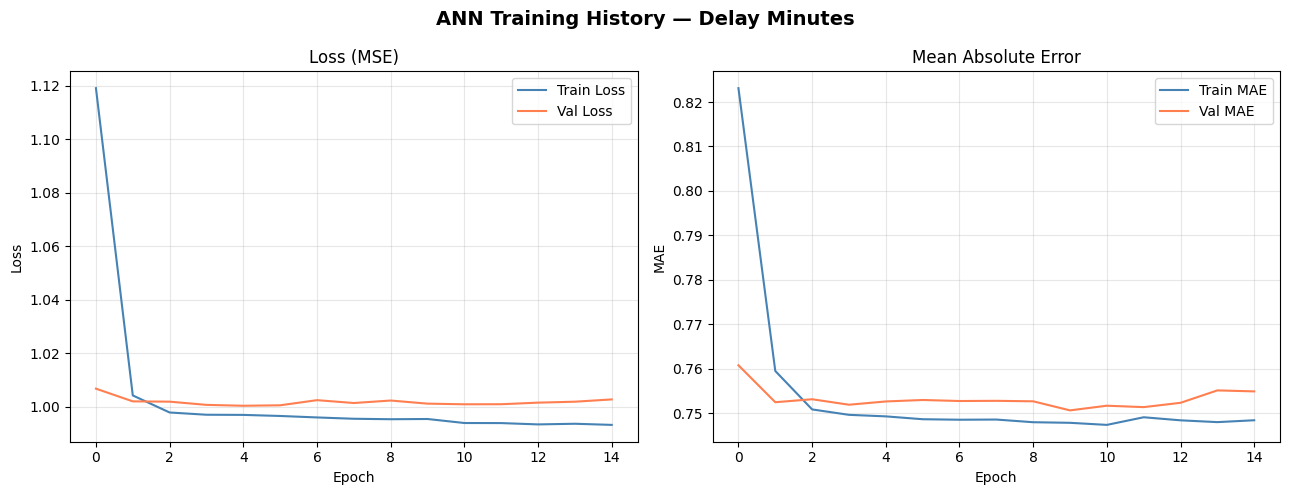

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('ANN Training History — Delay Minutes', fontsize=14, fontweight='bold')

axes[0].plot(history_delay.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history_delay.history['val_loss'], label='Val Loss', color='coral')
axes[0].set_title('Loss (MSE)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history_delay.history['mae'], label='Train MAE', color='steelblue')
axes[1].plot(history_delay.history['val_mae'], label='Val MAE', color='coral')
axes[1].set_title('Mean Absolute Error')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
y_delay_pred_scaled = ann_delay.predict(X_test).flatten()

# Inverse transform predictions
y_delay_pred = scaler_delay.inverse_transform(y_delay_pred_scaled.reshape(-1, 1)).flatten()
y_delay_true = scaler_delay.inverse_transform(y_delay_test.reshape(-1, 1)).flatten()

mse_ann  = mean_squared_error(y_delay_true, y_delay_pred)
rmse_ann = np.sqrt(mse_ann)
mae_ann  = mean_absolute_error(y_delay_true, y_delay_pred)
r2_ann   = r2_score(y_delay_true, y_delay_pred)

print('=== ANN — Delay Minutes Regression ===')
print(f'MSE  : {mse_ann:.4f}')
print(f'RMSE : {rmse_ann:.4f}')
print(f'MAE  : {mae_ann:.4f}')
print(f'R²   : {r2_ann:.4f}')

428/428 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
=== ANN — Delay Minutes Regression ===
MSE  : 896.4188
RMSE : 29.9403
MAE  : 22.4792
R²   : 0.0001


In [ ]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_delay_train)
y_lr_scaled = lr.predict(X_test)
y_lr = scaler_delay.inverse_transform(y_lr_scaled.reshape(-1, 1)).flatten()

# Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_delay_train)
y_rf_scaled = rf.predict(X_test)
y_rf = scaler_delay.inverse_transform(y_rf_scaled.reshape(-1, 1)).flatten()

# Results table
comparison = pd.DataFrame({
    'Model': ['ANN', 'Linear Regression', 'Random Forest'],
    'RMSE' : [rmse_ann,
               np.sqrt(mean_squared_error(y_delay_true, y_lr)),
               np.sqrt(mean_squared_error(y_delay_true, y_rf))],
    'MAE'  : [mae_ann,
               mean_absolute_error(y_delay_true, y_lr),
               mean_absolute_error(y_delay_true, y_rf)],
    'R²'   : [r2_ann,
               r2_score(y_delay_true, y_lr),
               r2_score(y_delay_true, y_rf)]
}).round(4)

print('=== Model Comparison — Delay Minutes Prediction ===')
print(comparison.to_string(index=False))

=== Model Comparison — Delay Minutes Prediction ===
            Model    RMSE     MAE      R²
              ANN 29.9403 22.4792  0.0001
Linear Regression 29.9369 22.4783  0.0003
    Random Forest 33.2515 24.9277 -0.2334


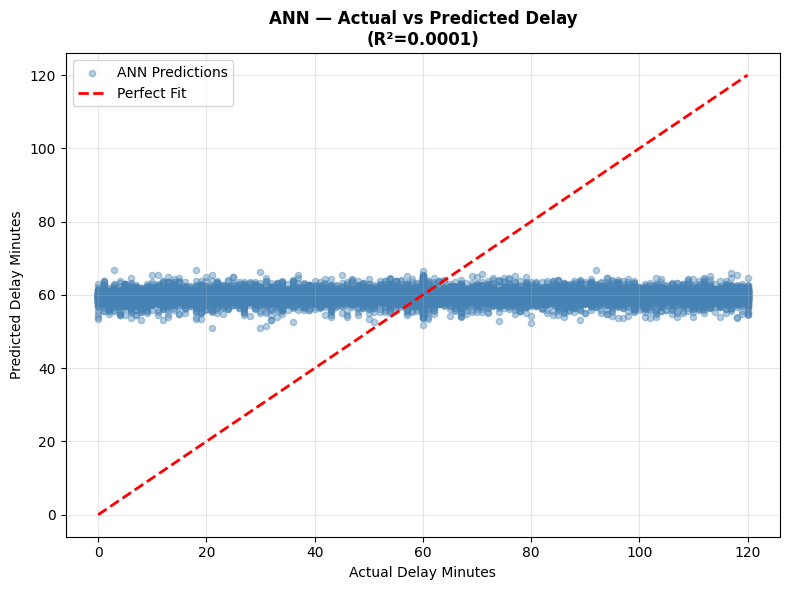

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_delay_true, y_delay_pred, alpha=0.4, color='steelblue', s=20, label='ANN Predictions')
min_val = min(y_delay_true.min(), y_delay_pred.min())
max_val = max(y_delay_true.max(), y_delay_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
plt.xlabel('Actual Delay Minutes')
plt.ylabel('Predicted Delay Minutes')
plt.title(f'ANN — Actual vs Predicted Delay\n(R²={r2_ann:.4f})', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
y_fuel_pred_scaled = ann_fuel.predict(X_test).flatten()
y_fuel_pred = scaler_fuel.inverse_transform(y_fuel_pred_scaled.reshape(-1, 1)).flatten()
y_fuel_true = scaler_fuel.inverse_transform(y_fuel_test.reshape(-1, 1)).flatten()

mse_fuel  = mean_squared_error(y_fuel_true, y_fuel_pred)
rmse_fuel = np.sqrt(mse_fuel)
mae_fuel  = mean_absolute_error(y_fuel_true, y_fuel_pred)
r2_fuel   = r2_score(y_fuel_true, y_fuel_pred)

print('=== ANN — Fuel Consumption Regression ===')
print(f'MSE  : {mse_fuel:.4f}')
print(f'RMSE : {rmse_fuel:.4f}')
print(f'MAE  : {mae_fuel:.4f}')
print(f'R²   : {r2_fuel:.4f}')

428/428 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
=== ANN — Fuel Consumption Regression ===
MSE  : 457593.8377
RMSE : 676.4568
MAE  : 332.1898
R²   : 0.9853


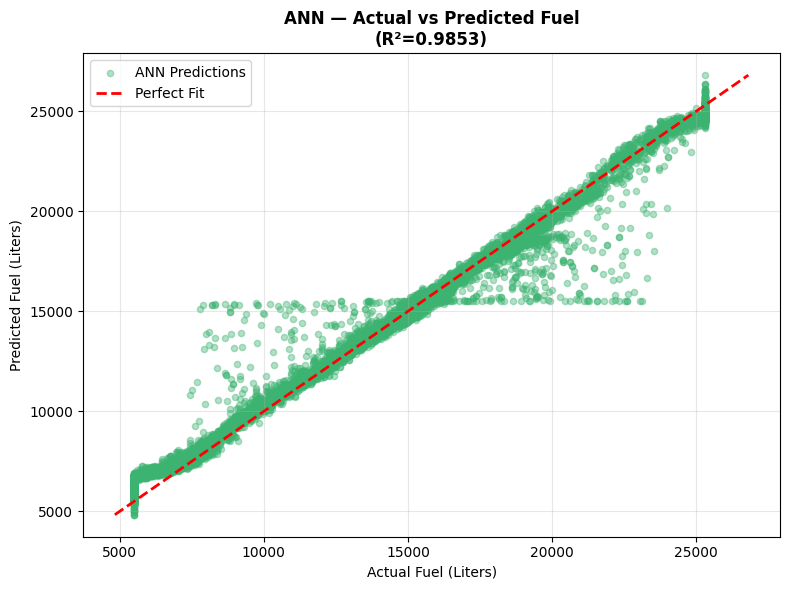

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_fuel_true, y_fuel_pred, alpha=0.4, color='mediumseagreen', s=20, label='ANN Predictions')
min_val = min(y_fuel_true.min(), y_fuel_pred.min())
max_val = max(y_fuel_true.max(), y_fuel_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
plt.xlabel('Actual Fuel (Liters)')
plt.ylabel('Predicted Fuel (Liters)')
plt.title(f'ANN — Actual vs Predicted Fuel\n(R²={r2_fuel:.4f})', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

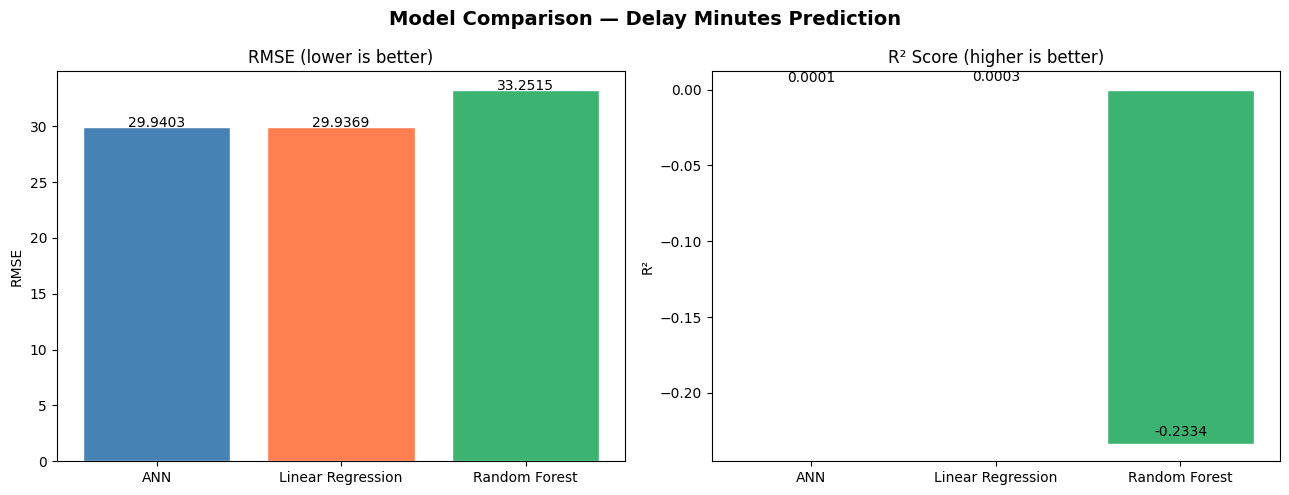

In [ ]:
models_list  = ['ANN', 'Linear Regression', 'Random Forest']
rmse_list    = comparison['RMSE'].tolist()
r2_list      = comparison['R²'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Comparison — Delay Minutes Prediction', fontsize=14, fontweight='bold')

colors = ['steelblue', 'coral', 'mediumseagreen']

bars1 = axes[0].bar(models_list, rmse_list, color=colors, edgecolor='white')
axes[0].set_title('RMSE (lower is better)')
axes[0].set_ylabel('RMSE')
for bar in bars1:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'{bar.get_height():.4f}', ha='center', fontsize=10)

bars2 = axes[1].bar(models_list, r2_list, color=colors, edgecolor='white')
axes[1].set_title('R² Score (higher is better)')
axes[1].set_ylabel('R²')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{bar.get_height():.4f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

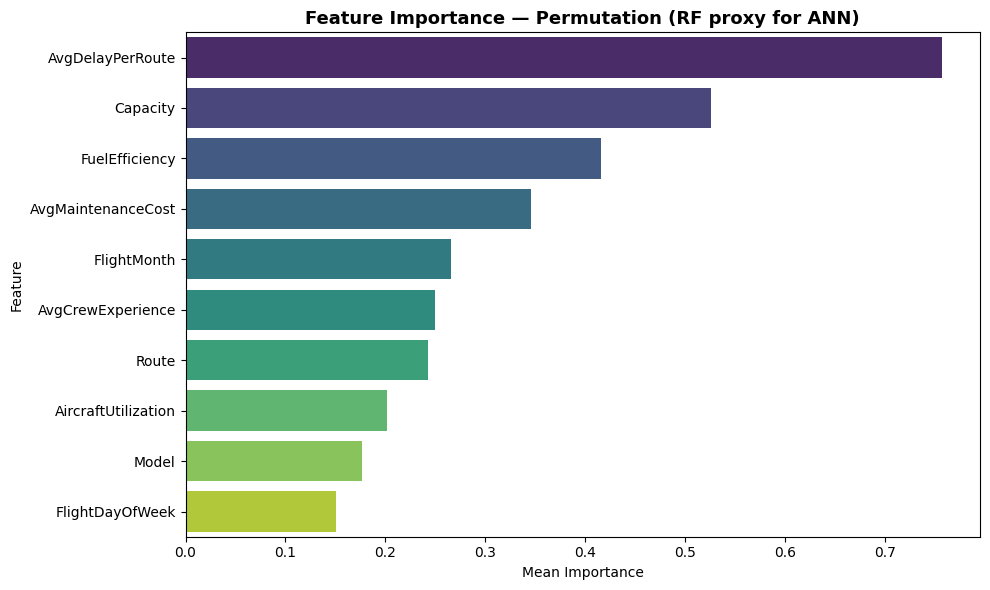


Top 5 features influencing delay:
           Feature  Importance
  AvgDelayPerRoute    0.757663
          Capacity    0.526016
    FuelEfficiency    0.415863
AvgMaintenanceCost    0.346284
       FlightMonth    0.265959


In [ ]:
from sklearn.inspection import permutation_importance

# Use Random Forest to get feature importances (proxy for ANN)
perm = permutation_importance(rf, X_test, y_rf_scaled, n_repeats=10, random_state=42)

feat_imp_df = pd.DataFrame({
    'Feature'   : feature_cols,
    'Importance': perm.importances_mean
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp_df, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance — Permutation (RF proxy for ANN)', fontsize=13, fontweight='bold')
plt.xlabel('Mean Importance')
plt.tight_layout()
plt.show()

print('\nTop 5 features influencing delay:')
print(feat_imp_df.head(5).to_string(index=False))

In [ ]:
print('='*55)
print('      PART 5 SUMMARY — ANN NEURAL NETWORK')
print('='*55)

print('\n📌 Task 1: Delay Minutes Prediction')
print(f'   ANN  RMSE : {rmse_ann:.4f}  | R²: {r2_ann:.4f}')
print(f'   LR   RMSE : {np.sqrt(mean_squared_error(y_delay_true, y_lr)):.4f}  | R²: {r2_score(y_delay_true, y_lr):.4f}')
print(f'   RF   RMSE : {np.sqrt(mean_squared_error(y_delay_true, y_rf)):.4f}  | R²: {r2_score(y_delay_true, y_rf):.4f}')

best = comparison.loc[comparison['R²'].idxmax(), 'Model']
print(f'\n   ✅ Best model: {best}')

print('\n📌 Task 2: Fuel Consumption Prediction')
print(f'   ANN  RMSE : {rmse_fuel:.4f}  | R²: {r2_fuel:.4f}')

print('\n📌 Q1: Does ANN improve prediction accuracy?')
ann_r2 = r2_ann
lr_r2  = r2_score(y_delay_true, y_lr)
rf_r2  = r2_score(y_delay_true, y_rf)
print(f'   ANN R²={ann_r2:.4f} vs LR R²={lr_r2:.4f} vs RF R²={rf_r2:.4f}')
print(f'   → {"Yes, ANN outperforms LR" if ann_r2 > lr_r2 else "LR performs comparably to ANN"}')

print('\n📌 Q2: Which features influence delay most?')
for i, row in feat_imp_df.head(3).iterrows():
    print(f'   {row["Feature"]} (importance={row["Importance"]:.4f})')

print('\n✅ PART 5 COMPLETE!')

      PART 5 SUMMARY — ANN NEURAL NETWORK

📌 Task 1: Delay Minutes Prediction
   ANN  RMSE : 29.9403  | R²: 0.0001
   LR   RMSE : 29.9369  | R²: 0.0003
   RF   RMSE : 33.2515  | R²: -0.2334

   ✅ Best model: Linear Regression

📌 Task 2: Fuel Consumption Prediction
   ANN  RMSE : 676.4568  | R²: 0.9853

📌 Q1: Does ANN improve prediction accuracy?
   ANN R²=0.0001 vs LR R²=0.0003 vs RF R²=-0.2334
   → LR performs comparably to ANN

📌 Q2: Which features influence delay most?
   AvgDelayPerRoute (importance=0.7577)
   Capacity (importance=0.5260)
   FuelEfficiency (importance=0.4159)

✅ PART 5 COMPLETE!


Part 6 : Advanced Analytics

In [ ]:
!pip install scikit-learn mlxtend --quiet
print('✅ Libraries installed!')

✅ Libraries installed!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

print('✅ All libraries imported!')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/airlines_preprocessed.csv')
print(f'✅ Loaded! Shape: {df.shape}')
df.head(3)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Loaded! Shape: (68413, 26)


,FlightID,AircraftID,SourceAirport,DestAirport,FlightDate,Model,Capacity,Airline,SourceAirportName,SourceCity,...,FuelUsed(Liters),AvgCrewExperience,AvgMaintenanceCost,Route,FlightMonth,FlightDayOfWeek,AircraftUtilization,AvgDelayPerRoute,FuelEfficiency,IsDelayed
0,1,32485,46637,31900,2023-07-30,A380,124,Indigo,New York_Airport_46637,New York,...,9992.0,10.5,276907.5,New York → Abu Dhabi,7,6,1,62.146409,80.580645,0
1,2,45342,14593,13349,2023-12-04,B737,102,Indigo,Mumbai_Airport_14593,Mumbai,...,17458.0,16.5,276907.5,Mumbai → London,12,0,1,57.858852,171.156863,0
2,3,47764,2985,5569,2023-07-26,B737,140,Emirates,New York_Airport_2985,New York,...,5496.5,4.5,276907.5,New York → Manchester,7,2,4,59.538283,33.071429,1


In [ ]:
# Combine delay rate + avg delay minutes per route
route_risk = df.groupby('Route').agg(
    DelayRate    = ('IsDelayed','mean'),
    AvgDelay     = ('DelayMinutes','mean'),
    FlightCount  = ('FlightID','count')
).reset_index()

route_risk['RiskScore'] = (
    0.5 * (route_risk['DelayRate'] / route_risk['DelayRate'].max()) +
    0.5 * (route_risk['AvgDelay']  / route_risk['AvgDelay'].max())
)

route_risk = route_risk.sort_values('RiskScore', ascending=False).reset_index(drop=True)

print('=== Top 10 High-Risk Routes ===')
print(route_risk.head(10)[['Route','DelayRate','AvgDelay','FlightCount','RiskScore']].to_string(index=False))

=== Top 10 High-Risk Routes ===
                   Route  DelayRate  AvgDelay  FlightCount  RiskScore
          Mumbai → Dubai   0.303136 60.268293          574   0.977212
          Dubai → London   0.290385 60.269231          520   0.956187
    Bangalore → New York   0.267091 63.146264          629   0.940546
        Chennai → London   0.283088 59.659926          544   0.939328
      London → Abu Dhabi   0.281046 59.596405          612   0.935456
    London → Los Angeles   0.275180 60.561151          556   0.933419
         Pune → New York   0.275980 60.010221          587   0.930376
      New York → Chennai   0.274510 60.190731          561   0.929381
        Pune → Abu Dhabi   0.273551 59.967391          552   0.926031
Los Angeles → Manchester   0.264414 61.634195          503   0.924158


In [ ]:
# Inefficiency score = high maintenance + high fuel + high delay
aircraft_df['NormMaint']  = (aircraft_df['AvgMaintenanceCost'] - aircraft_df['AvgMaintenanceCost'].min()) / \
                             (aircraft_df['AvgMaintenanceCost'].max() - aircraft_df['AvgMaintenanceCost'].min() + 1e-9)
aircraft_df['NormFuel']   = (aircraft_df['AvgFuelConsumption'] - aircraft_df['AvgFuelConsumption'].min()) / \
                             (aircraft_df['AvgFuelConsumption'].max() - aircraft_df['AvgFuelConsumption'].min() + 1e-9)
aircraft_df['NormDelay']  = (aircraft_df['DelayFrequency'] - aircraft_df['DelayFrequency'].min()) / \
                             (aircraft_df['DelayFrequency'].max() - aircraft_df['DelayFrequency'].min() + 1e-9)

aircraft_df['InefficScore'] = (
    0.4 * aircraft_df['NormMaint'] +
    0.3 * aircraft_df['NormFuel']  +
    0.3 * aircraft_df['NormDelay']
)

inefficient = aircraft_df.sort_values('InefficScore', ascending=False).head(10)
print('=== Top 10 Inefficient Aircraft ===')
print(inefficient[['AircraftID','Model','AvgMaintenanceCost',
                    'AvgFuelConsumption','DelayFrequency','InefficScore']].to_string(index=False))

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/airlines_preprocessed.csv') # Reload df to ensure correct state

# Bottleneck 1: Airports with most delays
airport_bottleneck = df.groupby('SourceCity').agg(
    DelayRate   = ('IsDelayed','mean'),
    AvgDelay    = ('DelayMinutes','mean'),
    TotalFlights= ('FlightID','count')
).reset_index().sort_values('DelayRate', ascending=False)

print('=== Top 10 Source Airport Bottlenecks ===')
print(airport_bottleneck.head(10).to_string(index=False))

print('\n=== Top 10 Destination Airport Bottlenecks ===')
dest_bottleneck = df.groupby('DestCity').agg(
    DelayRate   = ('IsDelayed','mean'),
    AvgDelay    = ('DelayMinutes','mean'),
    TotalFlights= ('FlightID','count')
).reset_index().sort_values('DelayRate', ascending=False)
print(dest_bottleneck.head(10).to_string(index=False))

# Bottleneck 2: Month-wise delay trend
month_delay = df.groupby('FlightMonth').agg(
    DelayRate = ('IsDelayed','mean'),
    AvgDelay  = ('DelayMinutes','mean')
).reset_index()
print('\n=== Monthly Delay Trend ===')
print(month_delay.to_string(index=False))

=== Top 10 Source Airport Bottlenecks ===
 SourceCity  DelayRate  AvgDelay  TotalFlights
    Chennai   0.252542 59.256642          6098
     London   0.250915 60.212092          6285
     Mumbai   0.246916 59.746175          6079
Los Angeles   0.246715 60.813239          6088
      Delhi   0.244413 60.185444          6444
 Manchester   0.243691 60.014628          6221
       Pune   0.243645 60.514948          6255
      Dubai   0.241219 60.001498          6007
   New York   0.240526 60.224084          6386
  Bangalore   0.237983 60.069976          6345

=== Top 10 Destination Airport Bottlenecks ===
  DestCity  DelayRate  AvgDelay  TotalFlights
    London   0.250476 60.314603          6300
     Dubai   0.250375 59.861828          6007
   Chennai   0.248554 60.881748          6224
Manchester   0.248527 60.259354          6281
 Abu Dhabi   0.244462 59.886853          6275
 Bangalore   0.243517 59.802024          6324
     Delhi   0.243130 59.784513          6186
  New York   0.241992 60.

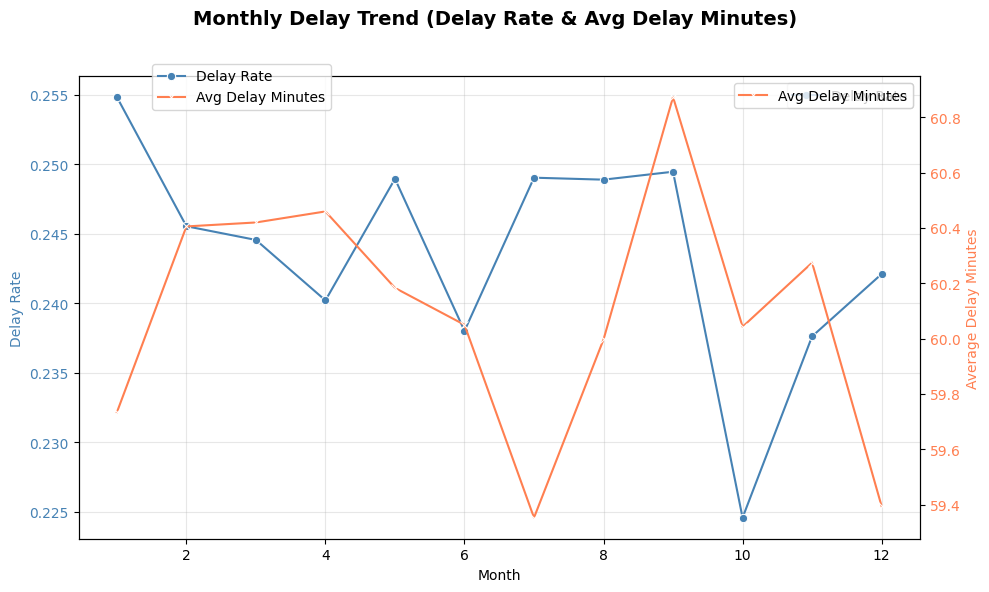

In [ ]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot DelayRate on the first y-axis
sns.lineplot(x='FlightMonth', y='DelayRate', data=month_delay, marker='o', color='steelblue', ax=ax1, label='Delay Rate')
ax1.set_xlabel('Month')
ax1.set_ylabel('Delay Rate', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.grid(alpha=0.3)

# Create a second y-axis for AvgDelay
ax2 = ax1.twinx()
sns.lineplot(x='FlightMonth', y='AvgDelay', data=month_delay, marker='x', color='coral', ax=ax2, label='Avg Delay Minutes')
ax2.set_ylabel('Average Delay Minutes', color='coral')
ax2.tick_params(axis='y', labelcolor='coral')

fig.suptitle('Monthly Delay Trend (Delay Rate & Avg Delay Minutes)', fontsize=14, fontweight='bold')
fig.legend(loc='upper left', bbox_to_anchor=(0.15, 0.9))
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

**part7:visualisation**

7.1 import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

7.2 load dataset

In [8]:
df = pd.read_csv('/content/drive/MyDrive/airlines_preprocessed.csv')
df.head()

,FlightID,AircraftID,SourceAirport,DestAirport,FlightDate,Model,Capacity,Airline,SourceAirportName,SourceCity,...,FuelUsed(Liters),AvgCrewExperience,AvgMaintenanceCost,Route,FlightMonth,FlightDayOfWeek,AircraftUtilization,AvgDelayPerRoute,FuelEfficiency,IsDelayed
0,1,32485,46637,31900,2023-07-30,A380,124,Indigo,New York_Airport_46637,New York,...,9992.0,10.5,276907.5,New York → Abu Dhabi,7,6,1,62.146409,80.580645,0
1,2,45342,14593,13349,2023-12-04,B737,102,Indigo,Mumbai_Airport_14593,Mumbai,...,17458.0,16.5,276907.5,Mumbai → London,12,0,1,57.858852,171.156863,0
2,3,47764,2985,5569,2023-07-26,B737,140,Emirates,New York_Airport_2985,New York,...,5496.5,4.5,276907.5,New York → Manchester,7,2,4,59.538283,33.071429,1
3,3,47764,2985,5569,2023-07-26,B737,140,Emirates,New York_Airport_2985,New York,...,5496.5,4.5,276907.5,New York → Manchester,7,2,4,59.538283,33.071429,1
4,3,47764,2985,5569,2023-07-26,B737,140,Emirates,New York_Airport_2985,New York,...,5496.5,4.5,276907.5,New York → Manchester,7,2,4,59.538283,33.071429,0


7.3 confusiton matrix

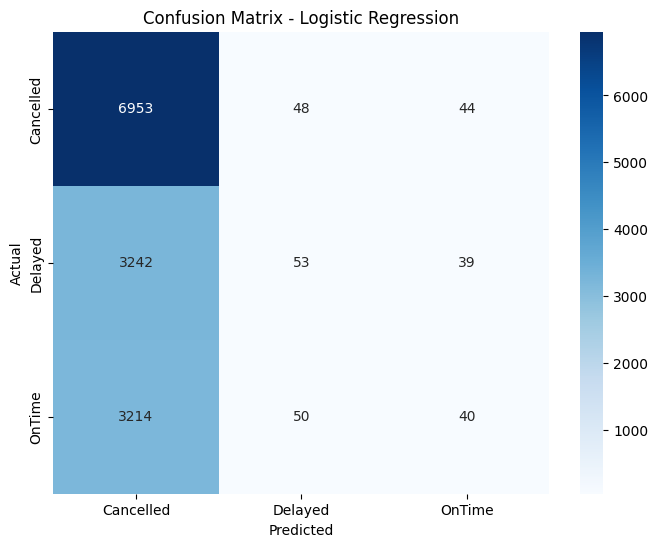

In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Re-define variables from Part 3 for independent execution within this cell
# Assuming df is already loaded from '/content/drive/MyDrive/airlines_preprocessed.csv'

feature_cols = ['Model', 'FuelUsed(Liters)', 'AvgCrewExperience',
                'Route', 'AvgMaintenanceCost', 'FlightMonth',
                'FlightDayOfWeek', 'AircraftUtilization', 'FuelEfficiency',
                'Capacity', 'AvgDelayPerRoute']

target_col = 'Status'

df_model = df[feature_cols + [target_col]].dropna().copy()

le_dict = {}
for col in df_model.select_dtypes(include='object').columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le

le_target = LabelEncoder()
df_model[target_col] = le_target.fit_transform(df_model[target_col].astype(str))

X = df_model[feature_cols]
y = df_model[target_col]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train only Logistic Regression model to get y_pred for the confusion matrix
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42)
}

results = {}
name = 'Logistic Regression'
model = models[name]
model.fit(X_train_scaled, y_train) # Use scaled data for LR
y_pred = model.predict(X_test_scaled)
results[name] = {'y_pred': y_pred} # Store only y_pred for confusion matrix

# Original plotting code starts here
model_name = 'Logistic Regression'
y_true_cm = y_test
y_pred_cm = results[model_name]['y_pred']

class_labels_cm = list(le_target.classes_)

cm = confusion_matrix(y_true_cm, y_pred_cm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_cm, yticklabels=class_labels_cm)
plt.title(f"Confusion Matrix - {model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

7.4 CLUSTER PLOT

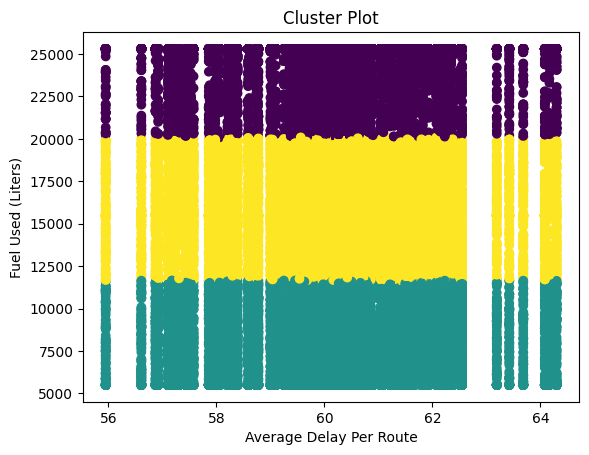

In [9]:
from sklearn.cluster import KMeans

X = df[['AvgDelayPerRoute', 'FuelUsed(Liters)']]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

plt.scatter(df['AvgDelayPerRoute'], df['FuelUsed(Liters)'], c=df['cluster'])
plt.xlabel("Average Delay Per Route")
plt.ylabel("Fuel Used (Liters)")
plt.title("Cluster Plot")
plt.show()

7.5 ROUTE DELAY HEATMAP

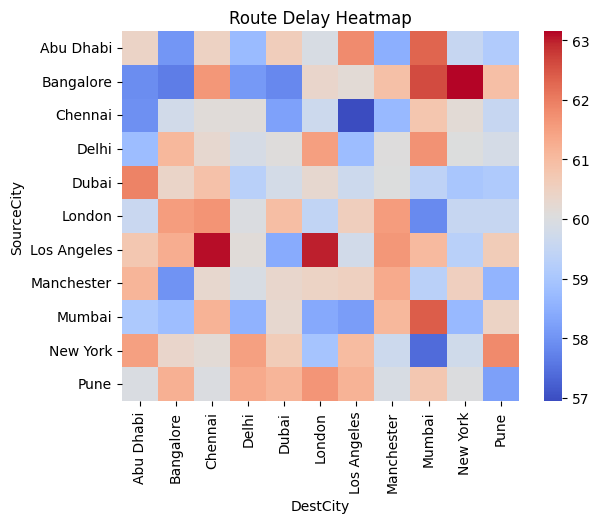

In [10]:
pivot_table = df.pivot_table(
    values='DelayMinutes',
    index='SourceCity',
    columns='DestCity',
    aggfunc='mean'
)

sns.heatmap(pivot_table, cmap='coolwarm')
plt.title("Route Delay Heatmap")
plt.show()

7.6 FUEL USAGE TREND

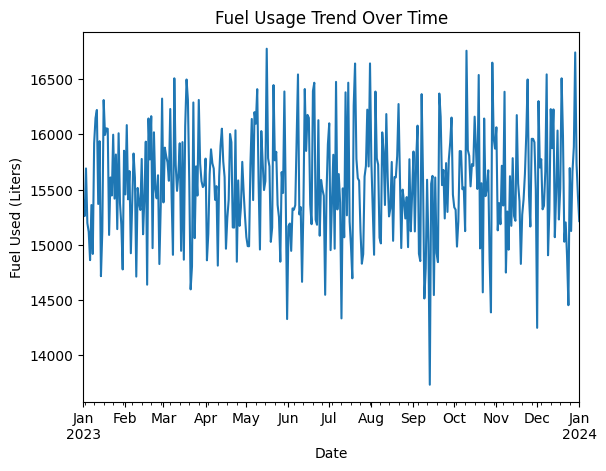

In [14]:
df['FlightDate'] = pd.to_datetime(df['FlightDate'])

fuel_trend = df.groupby('FlightDate')['FuelUsed(Liters)'].mean()

fuel_trend.plot()
plt.title("Fuel Usage Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Fuel Used (Liters)")
plt.show()